# PN-TDNN-DPD Training: CWGAN-GP with QAT

**Version:** 2.0 (Production)  
**Architecture:** Phase-Normalized TDNN (24-dim, M=3, 1,362 params)  
**Training:** CWGAN-GP + Spectral Loss + ILA  

## Key Design Decisions

| Component | Specification | Reason |
|-----------|--------------|--------|
| Input dim | 24 | 6 features × 4 taps (M=3) |
| Memory depth | M=3 | Captures >95% GaN PA memory |
| Feature extraction | Phase-normalized | Decouples amplitude/phase learning |
| Output activation | Linear (no Tanh) | Phase denorm bounds output naturally |
| Training | ILA | No PA model in loop |
| QAT | Q1.15 weights, Q8.8 activations | After epoch 300 |

In [2]:
# Install dependencies (run once)
!pip install -q torch torchvision torchaudio
!pip install -q numpy pandas matplotlib seaborn tqdm
!pip install -q scipy scikit-learn pyyaml tensorboard

print("✅ Dependencies installed!")

✅ Dependencies installed!


In [3]:
# Cell 1: Environment Setup
import os
import sys
from pathlib import Path

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

else:
    # Local development
    REPO_PATH = Path('.').resolve()
    sys.path.insert(0, str(REPO_PATH))

Mounted at /content/drive


In [4]:
# Set working directory
WORK_DIR = '/content/drive/MyDrive/FIX/6g-pa-gan-dpd' #change MyDrive to Revised as branch in gdrive
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

In [5]:
REPO_PATH = Path('/content/drive/MyDrive/FIX/6g-pa-gan-dpd')
print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {REPO_PATH}")

Working directory: /content/drive/MyDrive/FIX/6g-pa-gan-dpd
Python path includes: /content/drive/MyDrive/FIX/6g-pa-gan-dpd


In [6]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
import yaml
from typing import Dict, Tuple
from torch.utils.tensorboard import SummaryWriter
import gc

from models.pn_tdnn_generator import (
    PNTDNNGenerator,
    PhaseNormalizedFeatureExtraction,
    Discriminator,
    create_pn_tdnn_generator,
    create_discriminator
)

# Cell 9: Import differentiable NMSE for validation
from utils.spectral_loss import (
    SpectralLoss,
    compute_evm,
    compute_aclr,
    compute_nmse,
    compute_nmse_differentiable  # Add this import
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  Memory: 15.8 GB


In [ ]:
# Cell 3: Configuration (matches train.py and ARCHITECTURE.md)
config = {
    # Model architecture (FROZEN - matches ARCHITECTURE.md)
    'model': {
        'generator': {
            'memory_depth': 3,        # M=3 (24-dim input)
            'hidden_dims': [32, 16],  # FC layers
            'leaky_slope': 0.2,       # LeakyReLU
        },
        'discriminator': {
            'input_dim': 4,           # 2 (output) + 2 (condition)
            'hidden_dims': [64, 32],  # FC layers
            'leaky_slope': 0.2,
        }
    },

    # Dataset configuration (dpa_200mhz)
    'dataset': {
        'name': 'DPA_200MHz',
        'n_channels': 1,              # CHANGED: 1 channel (was 5 for apa_200mhz)
        'n_sub_channels': 10,         # CHANGED: 10 sub-channels (was 1 for apa_200mhz)
    },

    # Training hyperparameters
    'training': {
        'epochs': 500,
        'batch_size': 64,
        'n_critic': 5,                # WGAN-GP: train D 5x per G update
        'gp_weight': 10.0,            # Gradient penalty weight

        'optimizer': {
            'lr_generator': 1e-4,
            'lr_discriminator': 1e-4,
            'betas': [0.0, 0.9],      # WGAN-GP: no momentum
            'weight_decay': 1e-5,
        },

        'scheduler': {
            'type': 'cosine',
            'min_lr': 1e-6,
        },

        'loss': {
            'adversarial': 1.0,       # Wasserstein loss weight
            'reconstruction_l1': 40.0, # L1 loss weight
            'spectral': 10.0,         # Spectral loss weight
        },
    },

    # Early stopping configuration (NEW)
    'early_stopping': {
        'enabled': True,              # Enable early stopping
        'patience': 25,               # Stop if no improvement for 25 epochs
        'monitor': 'val_evm_db',      # Metric to monitor ('val_evm_db', 'val_nmse_db', 'val_l1')
        'min_delta': 0.01,            # Minimum improvement threshold (0.01 dB for EVM)
        'restore_best_weights': True, # Restore best model at end
    },

    # QAT configuration
    'qat': {
        'enabled': True,
        'start_epoch': 300,           # Enable QAT after float32 pre-training
        'weight_bits': 16,            # Q1.15
        'activation_bits': 16,        # Q8.8
    },

    # System parameters (CHANGED for dpa_200mhz)
    'system': {
        'sample_rate': 800e6,         # CHANGED: 200 MSps for dpa_200mhz (was 250 MSps)
    },

    # Spectral loss configuration (CRITICAL for dpa_200mhz)
    'spectral_loss': {
        'bw_main_ch': 200e6,          # Main channel 200 MHz
        'n_sub_ch': 10,               # CHANGED: 10 sub-channels for dpa_200mhz
        'nperseg': 2560,              # FFT segment length
    },

    # Logging
    'logging': {
        'log_interval': 100,
        'checkpoint_interval': 25,
    }
}

print("Configuration loaded:")
print(f"  Dataset: {config['dataset']['name']} ({config['dataset']['n_channels']} channel, {config['dataset']['n_sub_channels']} sub-channels)")
print(f"  Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"  Memory depth: M={config['model']['generator']['memory_depth']}")
print(f"  Input dim: {6 * (config['model']['generator']['memory_depth'] + 1)}")
print(f"  Hidden dims: {config['model']['generator']['hidden_dims']}")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  QAT starts at epoch: {config['qat']['start_epoch']}")
print(f"  Spectral Loss: {config['spectral_loss']['n_sub_ch']} sub-channels, {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz BW")
print(f"  Early Stopping: {config['early_stopping']['enabled']} (patience={config['early_stopping']['patience']}, monitor={config['early_stopping']['monitor']})")

Configuration loaded:
  Dataset: DPA_200MHz (1 channel, 10 sub-channels)
  Sample rate: 800 MSps
  Memory depth: M=3
  Input dim: 24
  Hidden dims: [32, 16]
  Epochs: 500
  QAT starts at epoch: 300
  Spectral Loss: 10 sub-channels, 200 MHz BW
  Early Stopping: True (patience=25, monitor=val_evm_db)


In [8]:
# Cell 4: Data Loading (matches train.py)
def load_measured_data(data_dir: Path, split: str = 'train'):
    """
    Load measured PA input/output data from CSV files.

    ILA convention:
    - u_pa: PA input (clean signal) -> TARGET for DPD
    - y_pa: PA output (distorted signal) -> INPUT to DPD
    """
    input_file = data_dir / f'{split}_input.csv'
    output_file = data_dir / f'{split}_output.csv'

    if not input_file.exists() or not output_file.exists():
        raise FileNotFoundError(f"Data files not found in {data_dir}")

    # Load CSV files
    input_df = pd.read_csv(input_file)
    output_df = pd.read_csv(output_file)

    # Convert to complex arrays
    u_pa = (input_df['I'].values + 1j * input_df['Q'].values).astype(np.complex64)
    y_pa = (output_df['I'].values + 1j * output_df['Q'].values).astype(np.complex64)

    # Normalize to -3 dBFS (0.7 linear)
    max_val = np.max(np.abs(u_pa))
    u_pa = u_pa / max_val * 0.7
    y_pa = y_pa / max_val * 0.7

    print(f"Loaded {len(u_pa):,} {split} samples")
    print(f"  PA input power:  {10*np.log10(np.mean(np.abs(u_pa)**2)):.2f} dBFS")
    print(f"  PA output power: {10*np.log10(np.mean(np.abs(y_pa)**2)):.2f} dBFS")

    return u_pa, y_pa

# Load data
data_dir = Path('data/DPA_200MHz')
u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')
u_pa_test, y_pa_test = load_measured_data(data_dir, 'test')

Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS
Loaded 7,680 test samples
  PA input power:  -11.80 dBFS
  PA output power: -1.77 dBFS


In [9]:
# Cell 5: Dataset Creation (matches train.py)
def create_dpd_dataset(u_pa: np.ndarray, y_pa: np.ndarray, memory_depth: int = 3) -> TensorDataset:
    """
    Create dataset for DPD training using Indirect Learning Architecture.

    ILA: DPD(y_PA) ≈ u_PA
    - Input to DPD: y_PA (distorted PA output)
    - Target: u_PA (clean PA input)

    PNTDNNGenerator handles phase-normalized feature extraction internally.
    We return raw IQ sequences [batch, M+1, 2].
    """
    num_samples = len(y_pa) - memory_depth

    # Input: raw IQ sequences from PA output
    inputs = np.zeros((num_samples, memory_depth + 1, 2), dtype=np.float32)
    # Target: IQ samples from PA input
    targets = np.zeros((num_samples, 2), dtype=np.float32)

    for i in range(num_samples):
        # Memory taps from PA output (time order: oldest to newest)
        for m in range(memory_depth + 1):
            idx = i + memory_depth - m
            inputs[i, m, 0] = y_pa[idx].real
            inputs[i, m, 1] = y_pa[idx].imag

        # Target is PA input at current time
        target_idx = i + memory_depth
        targets[i, 0] = u_pa[target_idx].real
        targets[i, 1] = u_pa[target_idx].imag

    return TensorDataset(torch.from_numpy(inputs), torch.from_numpy(targets))

# Create datasets
memory_depth = config['model']['generator']['memory_depth']
train_dataset = create_dpd_dataset(u_pa_train, y_pa_train, memory_depth)
val_dataset = create_dpd_dataset(u_pa_val, y_pa_val, memory_depth)
test_dataset = create_dpd_dataset(u_pa_test, y_pa_test, memory_depth)

# Create dataloaders
batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_dataset):,} samples, {len(train_loader):,} batches")
print(f"  Validation: {len(val_dataset):,} samples, {len(val_loader):,} batches")
print(f"  Test:       {len(test_dataset):,} samples, {len(test_loader):,} batches")


Dataset sizes:
  Training:   23,037 samples, 359 batches
  Validation: 7,677 samples, 120 batches
  Test:       7,677 samples, 120 batches


Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS


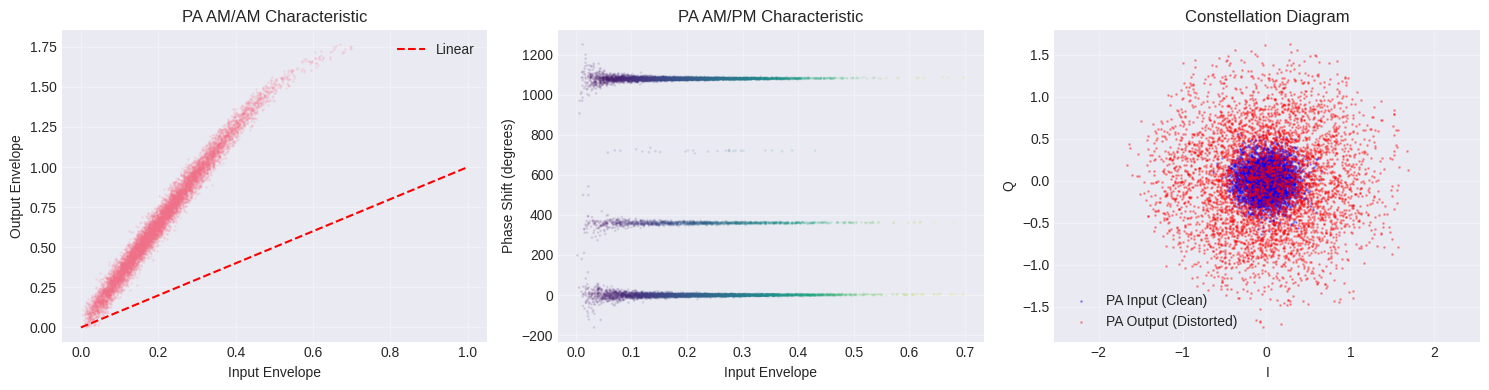


✅ Data loaded successfully!
   Training samples: 23,040
   Validation samples: 7,680


In [9]:
# # Cell 5a: PA Distortion and IQ Signal Visualization

try:
    u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
    u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')

    # Quick visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # AM/AM characteristic
    env_in = np.abs(u_pa_train[:10000])
    env_out = np.abs(y_pa_train[:10000])
    axes[0].scatter(env_in, env_out, alpha=0.1, s=1)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Linear')
    axes[0].set_xlabel('Input Envelope')
    axes[0].set_ylabel('Output Envelope')
    axes[0].set_title('PA AM/AM Characteristic')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # AM/PM characteristic
    phase_in = np.angle(u_pa_train[:10000])
    phase_out = np.angle(y_pa_train[:10000])
    phase_diff = np.unwrap(phase_out - phase_in)
    axes[1].scatter(env_in, np.degrees(phase_diff), alpha=0.1, s=1, c=env_in, cmap='viridis')
    axes[1].set_xlabel('Input Envelope')
    axes[1].set_ylabel('Phase Shift (degrees)')
    axes[1].set_title('PA AM/PM Characteristic')
    axes[1].grid(True, alpha=0.3)

    # Constellation
    axes[2].scatter(u_pa_train[:5000].real, u_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
    axes[2].scatter(y_pa_train[:5000].real, y_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
    axes[2].set_xlabel('I')
    axes[2].set_ylabel('Q')
    axes[2].set_title('Constellation Diagram')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].axis('equal')

    plt.tight_layout()
    plt.savefig('figures/pa_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Data loaded successfully!")
    print(f"   Training samples: {len(u_pa_train):,}")
    print(f"   Validation samples: {len(u_pa_val):,}")

except FileNotFoundError as e:
    print(f"\n❌ {e}")
    print("\nℹ️ Please upload your OpenDPD data files to the 'data' directory!")

Computing spectral analysis with 10 subchannels...


/tmp/ipython-input-212086781.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power_linear = np.trapz(psd[mask], freqs[mask])


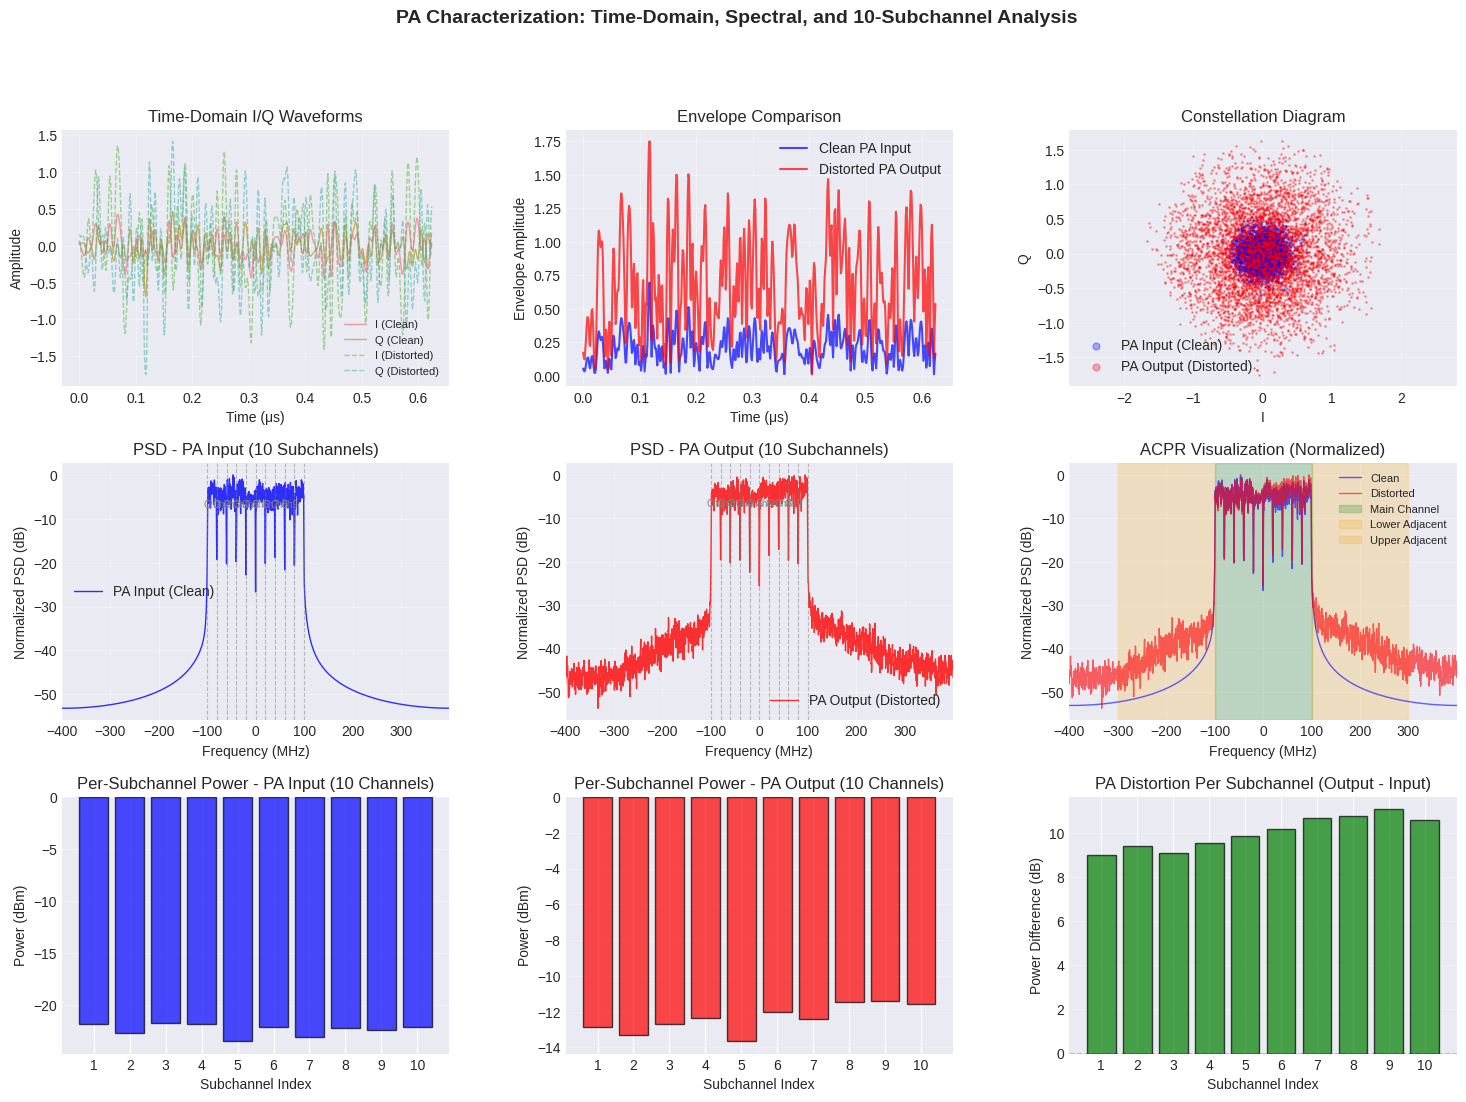


✅ Comprehensive visualization complete!
   Sample rate: 800 MSps
   Main channel BW: 200 MHz
   Subchannels: 10
   Subchannel BW: 20.0 MHz

   Mean power (Clean):     -22.37 dBm
   Mean power (Distorted): -12.37 dBm
   Power difference:       10.00 dB


In [10]:
# Cell 5b: Comprehensive Visualization - Time Domain, Spectral, and Per-Subchannel Analysis
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq, fftshift

def compute_psd_with_subchannels(signal_data, fs, nperseg=2560, n_sub_ch=10, bw_main_ch=200e6):
    """
    Compute PSD and identify subchannel boundaries.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        nperseg: FFT segment length
        n_sub_ch: Number of subchannels
        bw_main_ch: Main channel bandwidth (Hz)

    Returns:
        freqs: Frequency vector (Hz)
        psd_db: PSD in dBm/Hz
        subchannel_edges: List of (f_start, f_end) for each subchannel
    """
    # Compute PSD using Welch's method
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)

    # Shift to centered spectrum
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    # Convert to dBm/Hz (assuming 50 ohm impedance)
    psd_db = 10 * np.log10(psd + 1e-20)  # Add small value to avoid log(0)

    # Compute subchannel edges
    subchannel_bw = bw_main_ch / n_sub_ch
    f_start = -bw_main_ch / 2
    subchannel_edges = []
    for i in range(n_sub_ch):
        f_low = f_start + i * subchannel_bw
        f_high = f_low + subchannel_bw
        subchannel_edges.append((f_low, f_high))

    return freqs, psd_db, subchannel_edges

def compute_subchannel_power(signal_data, fs, subchannel_edges, nperseg=2560):
    """
    Compute power in each subchannel.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        subchannel_edges: List of (f_start, f_end) tuples
        nperseg: FFT segment length

    Returns:
        subchannel_powers: Array of power in dBm for each subchannel
    """
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    subchannel_powers = []
    for f_low, f_high in subchannel_edges:
        # Find indices within subchannel
        mask = (freqs >= f_low) & (freqs <= f_high)
        # Integrate PSD over subchannel bandwidth
        power_linear = np.trapz(psd[mask], freqs[mask])
        power_dbm = 10 * np.log10(power_linear + 1e-20)
        subchannel_powers.append(power_dbm)

    return np.array(subchannel_powers)

# Visualization parameters
fs = config['system']['sample_rate']  # 800e6 Hz
nperseg = config['spectral_loss']['nperseg']  # 2560
n_sub_ch = config['spectral_loss']['n_sub_ch']  # 10
bw_main_ch = config['spectral_loss']['bw_main_ch']  # 200e6 Hz

# Sample subset for visualization
n_samples = 10000
u_pa_vis = u_pa_train[:n_samples]
y_pa_vis = y_pa_train[:n_samples]

print("Computing spectral analysis with 10 subchannels...")

# Compute PSD and subchannel boundaries
freqs_clean, psd_clean, subchannel_edges = compute_psd_with_subchannels(
    u_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)
freqs_distorted, psd_distorted, _ = compute_psd_with_subchannels(
    y_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)

# Compute per-subchannel power
power_clean = compute_subchannel_power(u_pa_vis, fs, subchannel_edges, nperseg)
power_distorted = compute_subchannel_power(y_pa_vis, fs, subchannel_edges, nperseg)

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ===========================
# Row 1: Time-Domain Analysis
# ===========================

# Time-domain I/Q waveforms
ax1 = fig.add_subplot(gs[0, 0])
t_us = np.arange(500) / (fs / 1e6)  # First 500 samples in microseconds
ax1.plot(t_us, u_pa_vis[:500].real, label='I (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, u_pa_vis[:500].imag, label='Q (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, y_pa_vis[:500].real, label='I (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.plot(t_us, y_pa_vis[:500].imag, label='Q (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.set_xlabel('Time (μs)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Time-Domain I/Q Waveforms')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Envelope comparison
ax2 = fig.add_subplot(gs[0, 1])
env_clean = np.abs(u_pa_vis[:500])
env_distorted = np.abs(y_pa_vis[:500])
ax2.plot(t_us, env_clean, label='Clean PA Input', alpha=0.7, linewidth=1.5, color='blue')
ax2.plot(t_us, env_distorted, label='Distorted PA Output', alpha=0.7, linewidth=1.5, color='red')
ax2.set_xlabel('Time (μs)')
ax2.set_ylabel('Envelope Amplitude')
ax2.set_title('Envelope Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Constellation diagram
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(u_pa_vis[:5000].real, u_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
ax3.scatter(y_pa_vis[:5000].real, y_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
ax3.set_xlabel('I')
ax3.set_ylabel('Q')
ax3.set_title('Constellation Diagram')
ax3.legend(markerscale=5)
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# ===========================
# Row 2: Spectral Analysis with Subchannels
# ===========================

# Create normalized versions (0 dB peak)
psd_clean_norm = psd_clean - np.max(psd_clean)
psd_distorted_norm = psd_distorted - np.max(psd_distorted)

# PSD with subchannel boundaries (Clean)
ax4 = fig.add_subplot(gs[1, 0])
freqs_mhz = freqs_clean / 1e6
# CHANGE 1: Use psd_clean_norm instead of psd_clean
ax4.plot(freqs_mhz, psd_clean_norm, label='PA Input (Clean)', color='blue', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax4.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        # Dynamic text positioning will work fine with normalized data (0 - 10 = -10 dB)
        ax4.text((f_low + f_high) / 2 / 1e6, ax4.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax4.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax4.set_xlabel('Frequency (MHz)')
# CHANGE 2: Update label to 'Normalized PSD (dB)'
ax4.set_ylabel('Normalized PSD (dB)')
ax4.set_title(f'PSD - PA Input ({n_sub_ch} Subchannels)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD with subchannel boundaries (Distorted)
ax5 = fig.add_subplot(gs[1, 1])
# CHANGE 3: Use psd_distorted_norm instead of psd_distorted
ax5.plot(freqs_mhz, psd_distorted_norm, label='PA Output (Distorted)', color='red', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax5.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        ax5.text((f_low + f_high) / 2 / 1e6, ax5.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax5.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax5.set_xlabel('Frequency (MHz)')
# CHANGE 4: Update label
ax5.set_ylabel('Normalized PSD (dB)')
ax5.set_title(f'PSD - PA Output ({n_sub_ch} Subchannels)')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD Overlay for ACPR visualization
ax6 = fig.add_subplot(gs[1, 2])
# CHANGE 5 & 6: Use normalized versions for both
ax6.plot(freqs_mhz, psd_clean_norm, label='Clean', color='blue', linewidth=1, alpha=0.6)
ax6.plot(freqs_mhz, psd_distorted_norm, label='Distorted', color='red', linewidth=1, alpha=0.6)
# Highlight main channel and adjacent channels
main_ch_mask = (freqs_clean >= -bw_main_ch/2) & (freqs_clean <= bw_main_ch/2)
adj_lower_mask = (freqs_clean >= -3*bw_main_ch/2) & (freqs_clean < -bw_main_ch/2)
adj_upper_mask = (freqs_clean > bw_main_ch/2) & (freqs_clean <= 3*bw_main_ch/2)
ax6.axvspan(-bw_main_ch/2/1e6, bw_main_ch/2/1e6, alpha=0.2, color='green', label='Main Channel')
ax6.axvspan(-3*bw_main_ch/2/1e6, -bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Lower Adjacent')
ax6.axvspan(bw_main_ch/2/1e6, 3*bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Upper Adjacent')
ax6.set_xlabel('Frequency (MHz)')
ax6.set_ylabel('Normalized PSD (dB)')
ax6.set_title('ACPR Visualization (Normalized)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([freqs_mhz[0], freqs_mhz[-1]])
# Optional: Set Y-limit to focus on the top 80dB dynamic range
# ax6.set_ylim([-80, 5])

# ===========================
# Row 3: Per-Subchannel Analysis
# ===========================

# Per-subchannel power (Clean)
ax7 = fig.add_subplot(gs[2, 0])
subchannel_idx = np.arange(1, n_sub_ch + 1)
ax7.bar(subchannel_idx, power_clean, alpha=0.7, color='blue', edgecolor='black')
ax7.set_xlabel('Subchannel Index')
ax7.set_ylabel('Power (dBm)')
ax7.set_title(f'Per-Subchannel Power - PA Input ({n_sub_ch} Channels)')
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_xticks(subchannel_idx)

# Per-subchannel power (Distorted)
ax8 = fig.add_subplot(gs[2, 1])
ax8.bar(subchannel_idx, power_distorted, alpha=0.7, color='red', edgecolor='black')
ax8.set_xlabel('Subchannel Index')
ax8.set_ylabel('Power (dBm)')
ax8.set_title(f'Per-Subchannel Power - PA Output ({n_sub_ch} Channels)')
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_xticks(subchannel_idx)

# Per-subchannel power difference (Distortion)
ax9 = fig.add_subplot(gs[2, 2])
power_diff = power_distorted - power_clean
colors = ['green' if d > 0 else 'purple' for d in power_diff]
ax9.bar(subchannel_idx, power_diff, alpha=0.7, color=colors, edgecolor='black')
ax9.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax9.set_xlabel('Subchannel Index')
ax9.set_ylabel('Power Difference (dB)')
ax9.set_title(f'PA Distortion Per Subchannel (Output - Input)')
ax9.grid(True, alpha=0.3, axis='y')
ax9.set_xticks(subchannel_idx)

plt.suptitle(f'PA Characterization: Time-Domain, Spectral, and {n_sub_ch}-Subchannel Analysis',
             fontsize=14, fontweight='bold')

plt.savefig('figures/pa_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Comprehensive visualization complete!")
print(f"   Sample rate: {fs/1e6:.0f} MSps")
print(f"   Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"   Subchannels: {n_sub_ch}")
print(f"   Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"\n   Mean power (Clean):     {np.mean(power_clean):.2f} dBm")
print(f"   Mean power (Distorted): {np.mean(power_distorted):.2f} dBm")
print(f"   Power difference:       {np.mean(power_diff):.2f} dB")

Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...


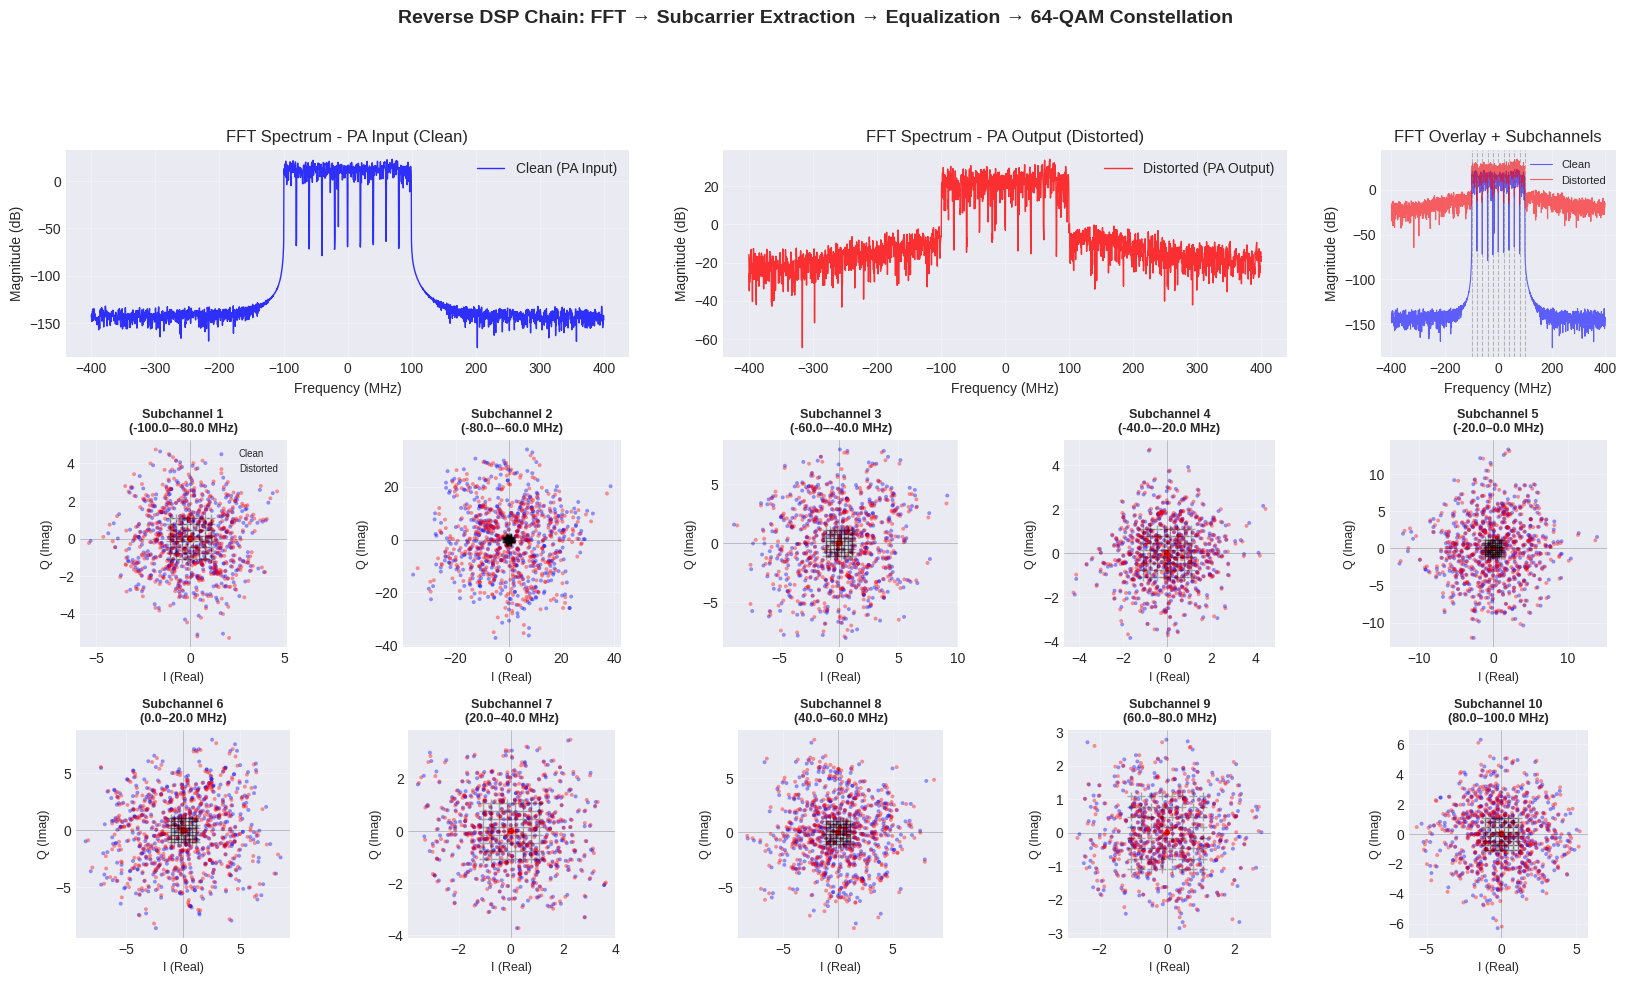


REVERSE DSP CHAIN ANALYSIS SUMMARY

FFT Configuration:
  Sample rate: 800 MSps
  FFT length: 2560 samples
  Main channel BW: 200 MHz
  Subchannel BW: 20.0 MHz
  Number of subchannels: 10

Equalization Method:
  Phase correction: Per-subchannel center frequency
  Amplitude normalization: Reference FFT bin magnitude

Per-Subchannel Equalized Constellation Statistics:
Channel    Clean (RMS)     Distorted (RMS)    EVM Increase   
------------------------------------------------------------
Ch 1       2.3146          2.3998              +3.68%
Ch 2       17.9544         17.2145             -4.12%
Ch 3       4.3583          4.2539              -2.39%
Ch 4       1.8576          1.8760              +0.99%
Ch 5       5.7010          5.6642              -0.64%
Ch 6       4.4928          4.3459              -3.27%
Ch 7       1.9216          1.9289              +0.38%
Ch 8       3.9718          4.1107              +3.50%
Ch 9       1.4511          1.4274              -1.64%
Ch 10      2.8084     

In [11]:
# Cell 6c: Reverse DSP Chain - 64-QAM Constellation with FFT, Subcarrier Extraction, and Equalization
def reverse_dsp_chain(time_domain_signal, fs, bw_main_ch=200e6, n_sub_ch=10, nperseg=2560):
    """
    Perform reverse DSP chain to extract 64-QAM constellation:
    1. Time-domain samples
    2. FFT (Fast Fourier Transform)
    3. Subcarrier extraction (10 subchannels)
    4. Channel equalization (phase/amplitude correction)
    5. QAM constellation visualization

    Args:
        time_domain_signal: Complex time-domain baseband signal
        fs: Sample rate (Hz)
        bw_main_ch: Main channel bandwidth (Hz)
        n_sub_ch: Number of subchannels
        nperseg: FFT segment length

    Returns:
        freqs: Frequency vector (Hz)
        fft_result: FFT magnitude spectrum
        subcarrier_data: Dict of per-subchannel data
        equalized_constellations: Dict of equalized I/Q constellations
    """

    # ===========================
    # Step 1: Apply window and FFT
    # ===========================
    window = scipy_signal.windows.hann(nperseg)
    n_segments = len(time_domain_signal) // nperseg

    # Process multiple segments and average for better SNR
    fft_segments = []
    subcarrier_segments = {i: [] for i in range(n_sub_ch)}

    for seg_idx in range(min(n_segments, 10)):  # Use up to 10 segments for averaging
        start_idx = seg_idx * nperseg
        end_idx = start_idx + nperseg
        segment = time_domain_signal[start_idx:end_idx]

        # Apply window
        windowed = segment * window

        # Compute FFT
        fft_vals = np.fft.fftshift(np.fft.fft(windowed))
        fft_segments.append(fft_vals)

        # ===========================
        # Step 2: Extract subcarriers
        # ===========================
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2

        for ch_idx in range(n_sub_ch):
            f_low = f_start + ch_idx * subchannel_bw
            f_high = f_low + subchannel_bw

            # Find FFT bins in this subchannel
            mask = (freqs >= f_low) & (freqs < f_high)
            subcarrier_data = fft_vals[mask]
            subcarrier_segments[ch_idx].append(subcarrier_data)

    # Average across segments
    fft_avg = np.mean(fft_segments, axis=0)

    # ===========================
    # Step 3: Channel Equalization
    # ===========================
    equalized_constellations = {}

    for ch_idx in range(n_sub_ch):
        # Collect all subcarrier samples
        subchannel_samples = np.concatenate(subcarrier_segments[ch_idx])

        # Estimate channel response from magnitude spectrum
        # Use strongest FFT bins in this subchannel as reference
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2 + ch_idx * subchannel_bw
        f_mid = f_start + subchannel_bw / 2

        # Find bin closest to subchannel center
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        center_bin = np.argmin(np.abs(freqs - f_mid))

        # Estimate phase from the strongest bin (channel phase rotation)
        ref_phase = np.angle(fft_avg[center_bin])
        ref_mag = np.abs(fft_avg[center_bin])

        # Equalize: correct phase rotation and normalize amplitude
        # Phase equalization: rotate by -ref_phase
        phase_corrected = subchannel_samples * np.exp(-1j * ref_phase)

        # Amplitude normalization: scale by reference magnitude
        if ref_mag > 0:
            equalized = phase_corrected / ref_mag
        else:
            equalized = phase_corrected

        equalized_constellations[ch_idx] = equalized

    return freqs, fft_avg, subcarrier_segments, equalized_constellations

# ===========================
# Generate 64-QAM Visualization
# ===========================

print("Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...")

# Use training data for visualization
n_samples_dsp = min(50000, len(u_pa_train))
u_pa_dsp = u_pa_train[:n_samples_dsp]
y_pa_dsp = y_pa_train[:n_samples_dsp]

# Perform reverse DSP chain
freqs_vec, fft_clean, subcarriers_clean, eq_constellations_clean = reverse_dsp_chain(
    u_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)
freqs_vec, fft_distorted, subcarriers_distorted, eq_constellations_distorted = reverse_dsp_chain(
    y_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)

# ===========================
# Create Visualization
# ===========================
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 5, hspace=0.4, wspace=0.4)

# ===========================
# Row 1: FFT and Spectrum
# ===========================

# Full FFT spectrum (Clean)
ax0 = fig.add_subplot(gs[0, :2])
freqs_mhz_dsp = freqs_vec / 1e6
fft_mag_clean = 20 * np.log10(np.abs(fft_clean) + 1e-20)
ax0.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=1, alpha=0.8, label='Clean (PA Input)')
ax0.set_xlabel('Frequency (MHz)')
ax0.set_ylabel('Magnitude (dB)')
ax0.set_title('FFT Spectrum - PA Input (Clean)')
ax0.grid(True, alpha=0.3)
ax0.legend()

# Full FFT spectrum (Distorted)
ax1 = fig.add_subplot(gs[0, 2:4])
fft_mag_distorted = 20 * np.log10(np.abs(fft_distorted) + 1e-20)
ax1.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=1, alpha=0.8, label='Distorted (PA Output)')
ax1.set_xlabel('Frequency (MHz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('FFT Spectrum - PA Output (Distorted)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# FFT Overlay with subchannel markers
ax2 = fig.add_subplot(gs[0, 4])
ax2.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=0.8, alpha=0.6, label='Clean')
ax2.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=0.8, alpha=0.6, label='Distorted')

# Mark subchannel boundaries
subchannel_bw = bw_main_ch / n_sub_ch
f_start = -bw_main_ch / 2
for i in range(n_sub_ch + 1):
    f_edge = f_start + i * subchannel_bw
    ax2.axvline(x=f_edge/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Magnitude (dB)')
ax2.set_title('FFT Overlay + Subchannels')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

# ===========================
# Rows 2-4: Per-Subchannel 64-QAM Constellations
# ===========================

# Layout: 10 subchannels in 2 rows × 5 columns
for ch_idx in range(n_sub_ch):
    row = 1 + (ch_idx // 5)
    col = ch_idx % 5
    ax = fig.add_subplot(gs[row, col])

    # Extract equalized constellation for this subchannel
    eq_const_clean = eq_constellations_clean[ch_idx]
    eq_const_distorted = eq_constellations_distorted[ch_idx]

    # Sample for visualization (to avoid overcrowding)
    sample_idx = np.random.choice(len(eq_const_clean), min(1000, len(eq_const_clean)), replace=False)

    # Plot clean constellation
    ax.scatter(eq_const_clean[sample_idx].real, eq_const_clean[sample_idx].imag,
              alpha=0.4, s=8, c='blue', label='Clean', edgecolors='none')

    # Plot distorted constellation
    ax.scatter(eq_const_distorted[sample_idx].real, eq_const_distorted[sample_idx].imag,
              alpha=0.4, s=8, c='red', label='Distorted', edgecolors='none')

    # Add reference 64-QAM grid (ideal points)
    qam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7]) / np.sqrt(42)  # Normalized 64-QAM
    for i_val in qam_levels:
        for q_val in qam_levels:
            ax.plot(i_val, q_val, 'k+', markersize=6, alpha=0.3)

    # Formatting
    ax.set_xlabel('I (Real)', fontsize=9)
    ax.set_ylabel('Q (Imag)', fontsize=9)
    ax.set_title(f'Subchannel {ch_idx+1}\n({f_start/1e6 + ch_idx*subchannel_bw/1e6:.1f}–{f_start/1e6 + (ch_idx+1)*subchannel_bw/1e6:.1f} MHz)',
                fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

    if ch_idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Reverse DSP Chain: FFT → Subcarrier Extraction → Equalization → 64-QAM Constellation',
             fontsize=14, fontweight='bold')

plt.savefig('figures/qam_constellation_reverse_dsp.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================
# Statistics Summary
# ===========================
print(f"\n{'='*80}")
print(f"REVERSE DSP CHAIN ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"\nFFT Configuration:")
print(f"  Sample rate: {fs/1e6:.0f} MSps")
print(f"  FFT length: {nperseg} samples")
print(f"  Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"  Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"  Number of subchannels: {n_sub_ch}")

print(f"\nEqualization Method:")
print(f"  Phase correction: Per-subchannel center frequency")
print(f"  Amplitude normalization: Reference FFT bin magnitude")

print(f"\nPer-Subchannel Equalized Constellation Statistics:")
print(f"{'Channel':<10} {'Clean (RMS)':<15} {'Distorted (RMS)':<18} {'EVM Increase':<15}")
print(f"{'-'*60}")

for ch_idx in range(n_sub_ch):
    eq_clean = eq_constellations_clean[ch_idx]
    eq_dist = eq_constellations_distorted[ch_idx]

    # RMS (quality metric)
    rms_clean = np.sqrt(np.mean(np.abs(eq_clean)**2))
    rms_dist = np.sqrt(np.mean(np.abs(eq_dist)**2))

    # EVM-like metric (normalized error)
    avg_clean = np.mean(np.abs(eq_clean))
    evm_increase = (np.std(eq_dist) / np.std(eq_clean) - 1) * 100 if np.std(eq_clean) > 0 else 0

    print(f"Ch {ch_idx+1:<7} {rms_clean:<15.4f} {rms_dist:<18.4f} {evm_increase:>+6.2f}%")

print(f"\n{'='*80}")
print(f"✅ Reverse DSP chain complete!")
print(f"   FFT bins extracted and analyzed")
print(f"   Phase rotation equalized per subchannel")
print(f"   64-QAM constellations visualized for all {n_sub_ch} subchannels")
print(f"{'='*80}")

In [10]:
# Cell 6: Model Creation (matches train.py)
# Generator: Phase-Normalized TDNN (24-dim input, 1,362 params)
generator = create_pn_tdnn_generator(memory_depth=config['model']['generator']['memory_depth'])
generator = generator.to(device)

# Discriminator: Conditional WGAN-GP (4-dim input)
discriminator = create_discriminator()
discriminator = discriminator.to(device)

# Verify architecture
g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())

print("Model Architecture Verification:")
print(f"  Generator:")
print(f"    Input dim: {generator.input_dim} (expected: 24)")
print(f"    Memory depth: M={generator.memory_depth} (expected: 3)")
print(f"    Hidden dims: {generator.hidden_dims}")
print(f"    Parameters: {g_params:,} (expected: 1,362)")
print(f"  Discriminator:")
print(f"    Parameters: {d_params:,}")

# Verify parameter count
assert g_params == 1362, f"Generator param count mismatch: {g_params} != 1362"
print("\n✓ Architecture verified!")

Model Architecture Verification:
  Generator:
    Input dim: 24 (expected: 24)
    Memory depth: M=3 (expected: 3)
    Hidden dims: [32, 16]
    Parameters: 1,362 (expected: 1,362)
  Discriminator:
    Parameters: 2,433

✓ Architecture verified!


In [11]:
# Cell 7: Optimizers and Schedulers (matches train.py)
opt_config = config['training']['optimizer']

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=opt_config['lr_generator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=opt_config['lr_discriminator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss
spectral_loss_fn = SpectralLoss(
    sample_rate=config['system']['sample_rate'],
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    nperseg=config['spectral_loss']['nperseg'],
    l1_weight=50.0,        # Unchanged (main loss)
    power_weight=10.0,     # Power regularization (reduced from old acpr_weight)
    nmse_weight=10.0,      # NEW: Differentiable NMSE loss
)

print("Spectral Loss initialized:")
print(f"  L1 weight: {spectral_loss_fn.l1_weight}")
print(f"  Power weight: {spectral_loss_fn.power_weight}")
print(f"  NMSE weight: {spectral_loss_fn.nmse_weight}")

print("Optimizers created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")

Spectral Loss initialized:
  L1 weight: 50.0
  Power weight: 10.0
  NMSE weight: 10.0
Optimizers created:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Betas: [0.0, 0.9]
  Scheduler: Cosine annealing to 1e-06


In [12]:
# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss with dpa_200mhz parameters
spectral_loss_fn = SpectralLoss(
    sample_rate=config['system']['sample_rate'],              # 800e6
    bw_main_ch=config['spectral_loss']['bw_main_ch'],        # 200e6
    n_sub_ch=config['spectral_loss']['n_sub_ch'],            # 10 (KEY CHANGE)
    nperseg=config['spectral_loss']['nperseg'],              # 2560
)

print("Optimizers and Loss Functions created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")
print(f"  SpectralLoss:")
print(f"    Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"    Main channel BW: {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz")
print(f"    Sub-channels: {config['spectral_loss']['n_sub_ch']}")

Optimizers and Loss Functions created:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Betas: [0.0, 0.9]
  Scheduler: Cosine annealing to 1e-06
  SpectralLoss:
    Sample rate: 800 MSps
    Main channel BW: 200 MHz
    Sub-channels: 10


In [15]:
def train_step(
    generator: nn.Module,
    discriminator: nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor],
    g_optimizer: optim.Optimizer,
    d_optimizer: optim.Optimizer,
    spectral_loss: SpectralLoss,
    config: dict,
    device: torch.device,
    step: int
) -> Dict[str, float]:
    """
    Single training step using Indirect Learning Architecture (ILA).

    In ILA:
    - Input: PA output (distorted signal y_PA)
    - Generator produces: Predistorted signal (should match clean PA input u_PA)
    - Target: PA input (clean signal u_PA)

    NO PA model in training loop - we train on measured data!

    Returns dictionary of loss values.
    """
    train_config = config['training']
    loss_config = train_config.get('loss', {})
    n_critic = train_config.get('n_critic', 5)
    gp_weight = train_config.get('gp_weight', 10.0)

    # Unpack batch
    input_seq, target = batch  # [B, M+1, 2], [B, 2]
    input_seq = input_seq.to(device)
    target = target.to(device)

    losses = {}

    # ===================
    # Train Discriminator
    # ===================
    for _ in range(n_critic):
        d_optimizer.zero_grad()

        # Generate DPD output (detach to prevent gradient flow)
        with torch.no_grad():
            dpd_output = generator(input_seq)  # [B, seq_len, 2]
            # Squeeze to [B, 2] if needed
            if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
                dpd_output = dpd_output.squeeze(1)

        # Discriminator loss components
        # Real: clean PA input (what DPD should produce)
        # Fake: DPD output (what DPD actually produces)
        # Condition: Current PA output sample (what DPD saw)
        condition = input_seq[:, -1, :]  # [B, 2] - most recent sample

        # Critic scores
        d_real = discriminator(target, condition)  # [B, 1]
        d_fake = discriminator(dpd_output.detach(), condition)  # [B, 1]

        # Wasserstein loss: maximize D(real) - D(fake)
        d_loss = d_fake.mean() - d_real.mean()

        # Gradient penalty: enforce 1-Lipschitz constraint
        batch_size = target.size(0)
        alpha = torch.rand(batch_size, 1, device=device)
        interpolates = alpha * target + (1 - alpha) * dpd_output.detach()
        interpolates.requires_grad_(True)

        d_interp = discriminator(interpolates, condition)

        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients_norm = gradients.view(batch_size, -1).norm(2, dim=1)
        gp = ((gradients_norm - 1) ** 2).mean()

        d_total = d_loss + gp_weight * gp
        d_total.backward()
        d_optimizer.step()

    losses['d_wasserstein'] = d_loss.item()
    losses['d_gp'] = gp.item()
    losses['d_total'] = d_total.item()

    # =================
    # Train Generator
    # =================
    g_optimizer.zero_grad()

    # Generate DPD output
    dpd_output = generator(input_seq)  # [B, seq_len - M, 2] → [B, 1, 2] for M=3

    # Squeeze to [B, 2] for all downstream uses
    if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
        dpd_output = dpd_output.squeeze(1)  # Now [B, 2]

    # Now use dpd_output everywhere else - it's always [B, 2]
    condition = input_seq[:, -1, :]  # [B, 2]

    # Reconstruction loss (L1: DPD output should match PA input)
    recon_loss = nn.functional.l1_loss(dpd_output, target)

    # Discriminator loss
    d_fake = discriminator(dpd_output, condition)  # [B, 1]
    g_adv_loss = -d_fake.mean()

    # Spectral loss
    spectral, spectral_components = spectral_loss(dpd_output, target, return_components=True)

    # Combined generator loss with weighted components
    g_total = (
        loss_config.get('adversarial', 1.0) * g_adv_loss +
        loss_config.get('reconstruction_l1', 50.0) * recon_loss +
        loss_config.get('spectral', 10.0) * spectral
    )

    g_total.backward()
    g_optimizer.step()

    losses['g_adv'] = g_adv_loss.item()
    losses['g_recon'] = recon_loss.item()
    losses['g_spectral'] = spectral.item()
    losses['g_total'] = g_total.item()
    losses.update({f'g_{k}': v.item() for k, v in spectral_components.items()})

    return losses

In [13]:
# Cell 9: UPDATED Validation Function with Sequence Aggregation
def validate(generator, val_loader, spectral_loss_fn, device):
    """
    Validate model on validation set with sequence aggregation for spectral metrics.

    Strategy:
    - Aggregate ALL validation outputs into long sequences
    - Compute EVM/ACLR on aggregated sequences (requires long data for FFT/Welch)
    - Compute NMSE per-batch and average (works on short sequences)
    """
    generator.eval()

    # Collect all predictions and targets for aggregation
    all_predictions = []
    all_targets = []
    all_nmse = []
    all_l1 = []

    with torch.no_grad():
        for input_seq, target in val_loader:
            input_seq = input_seq.to(device)
            target = target.to(device)

            # Generate predictions
            dpd_output = generator(input_seq)

            # Squeeze if needed
            if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
                dpd_output = dpd_output.squeeze(1)

            # Store for aggregation
            all_predictions.append(dpd_output.cpu())
            all_targets.append(target.cpu())

            # Compute NMSE per batch (works on any length)
            try:
                nmse = compute_nmse_differentiable(dpd_output, target, return_db=True)
                all_nmse.append(nmse.item())
            except:
                all_nmse.append(-50.0)

            # Compute L1 error
            l1_error = torch.nn.functional.l1_loss(dpd_output, target)
            all_l1.append(l1_error.item())

    # Aggregate all predictions and targets
    all_predictions_cat = torch.cat(all_predictions, dim=0)  # [total_samples, 2]
    all_targets_cat = torch.cat(all_targets, dim=0)          # [total_samples, 2]

    # Convert to numpy for spectral metrics
    pred_np = all_predictions_cat.numpy()  # [N, 2]
    target_np = all_targets_cat.numpy()    # [N, 2]

    # Reshape to [1, N, 2] for spectral metric functions (they expect [batch, seq, 2])
    pred_np = pred_np.reshape(1, -1, 2)
    target_np = target_np.reshape(1, -1, 2)

    print(f"  [Validation] Aggregated {pred_np.shape[1]} samples for spectral metrics")

    # Compute EVM on aggregated sequence
    try:
        evm_db = compute_evm(
            pred_np, target_np,
            sample_rate=spectral_loss_fn.sample_rate,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            nperseg=spectral_loss_fn.nperseg,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: EVM computation failed: {e}")
        evm_db = -50.0

    # Compute ACLR on aggregated sequence
    try:
        aclr_l, aclr_r = compute_aclr(
            pred_np,
            sample_rate=spectral_loss_fn.sample_rate,
            nperseg=spectral_loss_fn.nperseg,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: ACLR computation failed: {e}")
        aclr_l = -50.0
        aclr_r = -50.0

    generator.train()

    return {
        'val_evm_db': evm_db,
        'val_nmse_db': np.mean(all_nmse),
        'val_aclr_lower_db': aclr_l,
        'val_aclr_upper_db': aclr_r,
        'val_l1': np.mean(all_l1)
    }

print("Validation function defined (with sequence aggregation)")

Validation function defined (with sequence aggregation)


In [14]:
# Cell 9b (ENHANCED): Checkpoint Management with Error Handling & Memory Optimization

def save_checkpoint(checkpoint_dir, epoch, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, history, best_evm, best_state, early_stopping_counter,
                   early_stopping_best_value, qat_enabled, config, verbose=True):
    """
    Save training checkpoint for resumption with error handling and cleanup.

    Args:
        checkpoint_dir: Directory to save checkpoint
        epoch: Current epoch number
        generator: Generator model
        discriminator: Discriminator model
        g_optimizer, d_optimizer: Optimizers
        g_scheduler, d_scheduler: Learning rate schedulers
        history: Training history dict
        best_evm: Best EVM achieved
        best_state: Best model state dict
        early_stopping_counter: ES counter
        early_stopping_best_value: Best value for ES
        qat_enabled: Whether QAT is enabled
        config: Config dict
        verbose: Print status messages

    Returns:
        checkpoint_path: Path to saved checkpoint
    """
    try:
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

        checkpoint = {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'g_scheduler_state_dict': g_scheduler.state_dict(),
            'd_scheduler_state_dict': d_scheduler.state_dict(),
            'history': history,
            'best_evm': best_evm,
            'best_state': best_state,
            'early_stopping_counter': early_stopping_counter,
            'early_stopping_best_value': early_stopping_best_value,
            'qat_enabled': qat_enabled,
            'config': config,
            'timestamp': datetime.now().isoformat(),
        }

        # Save epoch checkpoint
        checkpoint_path = checkpoint_dir / f'checkpoint_epoch_{epoch:03d}.pth'
        torch.save(checkpoint, checkpoint_path)

        # Save as 'latest' for easy resumption
        latest_path = checkpoint_dir / 'checkpoint_latest.pth'
        torch.save(checkpoint, latest_path)

        if verbose:
            checkpoint_size_mb = checkpoint_path.stat().st_size / (1024 * 1024)
            print(f"✓ Checkpoint saved: {checkpoint_path.name} ({checkpoint_size_mb:.1f} MB)")

        # Cleanup: Keep only last 3 checkpoints to save disk space
        checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
        if len(checkpoints) > 3:
            for old_cp in checkpoints[:-3]:
                try:
                    old_cp.unlink()  # Delete file
                    if verbose:
                        print(f"  Cleaned up: {old_cp.name}")
                except Exception as e:
                    if verbose:
                        print(f"  Warning: Could not delete {old_cp.name}: {e}")

        return checkpoint_path

    except Exception as e:
        print(f"❌ ERROR: Failed to save checkpoint at epoch {epoch}: {e}")
        raise


def load_checkpoint(checkpoint_path, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, device):
    """
    Load checkpoint and resume training with validation.

    Args:
        checkpoint_path: Path to checkpoint file
        generator, discriminator: Models to load into
        g_optimizer, d_optimizer: Optimizers to restore
        g_scheduler, d_scheduler: Schedulers to restore
        device: Device (cuda/cpu)

    Returns:
        Tuple of (history, best_evm, best_state, early_stopping_counter,
                  early_stopping_best_value, qat_enabled, resume_epoch)
    """
    try:
        print(f"Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)

        # Validate checkpoint contents
        required_keys = [
            'generator_state_dict', 'discriminator_state_dict',
            'g_optimizer_state_dict', 'd_optimizer_state_dict',
            'g_scheduler_state_dict', 'd_scheduler_state_dict',
            'history', 'best_evm', 'best_state'
        ]
        for key in required_keys:
            if key not in checkpoint:
                raise KeyError(f"Missing required key in checkpoint: {key}")

        # Load model and optimizer states
        generator.load_state_dict(checkpoint['generator_state_dict'])
        discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
        d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
        g_scheduler.load_state_dict(checkpoint['g_scheduler_state_dict'])
        d_scheduler.load_state_dict(checkpoint['d_scheduler_state_dict'])

        # Restore training state
        history = checkpoint['history']
        best_evm = checkpoint['best_evm']
        best_state = checkpoint['best_state']
        early_stopping_counter = checkpoint.get('early_stopping_counter', 0)
        early_stopping_best_value = checkpoint.get('early_stopping_best_value', float('inf'))
        qat_enabled = checkpoint.get('qat_enabled', False)
        resume_epoch = checkpoint['epoch']

        # Get checkpoint timestamp if available
        timestamp = checkpoint.get('timestamp', 'unknown')

        print(f"\n✓ Checkpoint loaded successfully!")
        print(f"  Saved at: {timestamp}")
        print(f"  Resuming from epoch: {resume_epoch + 1}")
        print(f"  Best EVM so far: {best_evm:.2f} dB")
        print(f"  QAT status: {'Enabled' if qat_enabled else 'Disabled'}")
        print(f"  Early stopping counter: {early_stopping_counter}/25")
        print(f"  Training epochs completed: {len(history['g_total'])}")

        return history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, resume_epoch

    except FileNotFoundError:
        print(f"❌ ERROR: Checkpoint file not found: {checkpoint_path}")
        raise
    except Exception as e:
        print(f"❌ ERROR: Failed to load checkpoint: {e}")
        raise


def cleanup_checkpoint_memory():
    """
    Clear GPU memory after checkpoint operations.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_checkpoint_status(checkpoint_dir):
    """
    Get status of all checkpoints in directory.

    Returns:
        Dict with checkpoint information
    """
    checkpoint_dir = Path(checkpoint_dir)

    if not checkpoint_dir.exists():
        return {
            'exists': False,
            'count': 0,
            'latest': None,
            'checkpoints': []
        }

    checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
    latest = checkpoint_dir / 'checkpoint_latest.pth'

    checkpoint_info = []
    for cp in checkpoints:
        size_mb = cp.stat().st_size / (1024 * 1024)
        epoch = int(cp.stem.split('_')[-1])
        checkpoint_info.append({
            'path': cp,
            'epoch': epoch,
            'size_mb': size_mb,
            'name': cp.name
        })

    return {
        'exists': latest.exists(),
        'count': len(checkpoints),
        'latest': latest if latest.exists() else None,
        'checkpoints': checkpoint_info
    }


print("✓ Checkpoint management functions defined (enhanced)")

✓ Checkpoint management functions defined (enhanced)


In [18]:
# Cell 10: Training Loop with QAT Transition, Early Stopping, and Checkpoint Resumption
# Cell 10 (ENHANCED): Training Loop with Checkpointing & Auto-Resume

# ===== CHECKPOINT CONFIGURATION =====
checkpoint_dir = Path('checkpoints/training')
resume_checkpoint = checkpoint_dir / 'checkpoint_latest.pth'

# Auto-detect checkpoint (set to False to start fresh)
RESUME_FROM_CHECKPOINT = resume_checkpoint.exists()

# OVERRIDE: Force specific behavior
# RESUME_FROM_CHECKPOINT = True   # Uncomment to force resume
# RESUME_FROM_CHECKPOINT = False  # Uncomment to force fresh start

print("="*70)
print("CHECKPOINT & RESUMPTION CONFIGURATION")
print("="*70)

# Show checkpoint status
cp_status = get_checkpoint_status(checkpoint_dir)
print(f"\nCheckpoint Directory: {checkpoint_dir}")
print(f"Checkpoints exist: {cp_status['exists']}")
print(f"Checkpoint count: {cp_status['count']}")

if cp_status['checkpoints']:
    print(f"\nRecent checkpoints:")
    for cp_info in cp_status['checkpoints'][-3:]:  # Show last 3
        print(f"  Epoch {cp_info['epoch']:3d}: {cp_info['name']} ({cp_info['size_mb']:.1f} MB)")

print(f"\nResume mode: {'AUTO-RESUME' if RESUME_FROM_CHECKPOINT else 'FRESH START'}")
print("="*70)

# Setup TensorBoard logging
if RESUME_FROM_CHECKPOINT:
    run_name = f"pn_tdnn_dpa200mhz_resumed_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
else:
    run_name = f"pn_tdnn_dpa200mhz_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

tensorboard_dir = Path('runs') / run_name
tensorboard_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(str(tensorboard_dir))

print(f"\nTensorBoard logs: {tensorboard_dir}")
print(f"View with: tensorboard --logdir=runs/")

# Initialize or load training state
if RESUME_FROM_CHECKPOINT:
    print("\n" + "="*70)
    print("RESUMING FROM CHECKPOINT")
    print("="*70)
    try:
        history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, start_epoch = load_checkpoint(
            resume_checkpoint, generator, discriminator, g_optimizer, d_optimizer, g_scheduler, d_scheduler, device
        )
        start_epoch += 1  # Start from next epoch
        cleanup_checkpoint_memory()

        print(f"\n✓ Ready to resume training from epoch {start_epoch + 1}")

    except Exception as e:
        print(f"\n❌ Failed to load checkpoint: {e}")
        print("Starting fresh training instead...")
        RESUME_FROM_CHECKPOINT = False
else:
    print("\nStarting fresh training")

# Only initialize fresh if not resuming
if not RESUME_FROM_CHECKPOINT:
    history = {
        'g_total': [], 'd_total': [], 'g_adv': [], 'g_recon': [], 'g_spectral': [],
        'val_evm_db': [], 'val_nmse_db': [], 'val_aclr_lower_db': [], 'val_aclr_upper_db': [], 'val_l1': [], 'lr': []
    }
    best_evm = float('inf')
    best_state = None
    early_stopping_counter = 0
    early_stopping_best_value = float('inf')
    qat_enabled = False
    start_epoch = 0

# Early stopping configuration
es_config = config['early_stopping']
early_stopping_enabled = es_config['enabled']
early_stopping_patience = es_config['patience']
early_stopping_monitor = es_config['monitor']
early_stopping_min_delta = es_config['min_delta']
early_stopped = False

# QAT configuration
qat_start_epoch = config['qat']['start_epoch']

print(f"\nTraining Configuration:")
print(f"  Starting epoch: {start_epoch + 1}/{num_epochs}")
print(f"  QAT enabled at epoch: {qat_start_epoch}")
print(f"  Early stopping: {'ON' if early_stopping_enabled else 'OFF'} (patience={early_stopping_patience})")
print(f"  Checkpoint interval: {config['logging'].get('checkpoint_interval', 25)} epochs")
print("="*70)

# ===== MAIN TRAINING LOOP =====
for epoch in range(start_epoch, num_epochs):
    if early_stopped:
        print(f"\n{'='*70}")
        print(f"EARLY STOPPING TRIGGERED")
        print(f"  No improvement for {early_stopping_patience} epochs")
        print(f"  Best {early_stopping_monitor}: {early_stopping_best_value:.4f}")
        print(f"{'='*70}")
        break

    generator.train()
    discriminator.train()

    # ==================
    # QAT Transition
    # ==================
    if epoch == qat_start_epoch and config['qat']['enabled'] and not qat_enabled:
        generator.enable_qat()
        qat_enabled = True
        print(f"\n{'='*70}")
        print(f"QAT ENABLED at epoch {epoch + 1}")
        print(f"  Weight quantization: Q1.15 ({config['qat']['weight_bits']} bits)")
        print(f"  Activation quantization: Q8.8 ({config['qat']['activation_bits']} bits)")
        print(f"{'='*70}\n")

    # ==================
    # Training epoch
    # ==================
    epoch_losses = {}
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [{"QAT" if qat_enabled else "FP32"}]')

    for batch_idx, batch in enumerate(pbar):
        global_step = epoch * len(train_loader) + batch_idx
        losses = train_step(
            generator, discriminator, batch,
            g_optimizer, d_optimizer, spectral_loss_fn,
            config, device, global_step
        )

        for k, v in losses.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v

        # TensorBoard logging per batch
        writer.add_scalar('Train/Generator/Total', losses['g_total'], global_step)
        writer.add_scalar('Train/Generator/Adversarial', losses['g_adv'], global_step)
        writer.add_scalar('Train/Generator/Reconstruction', losses['g_recon'], global_step)
        writer.add_scalar('Train/Generator/Spectral', losses['g_spectral'], global_step)
        writer.add_scalar('Train/Discriminator/Wasserstein', losses['d_wasserstein'], global_step)
        writer.add_scalar('Train/Discriminator/GradientPenalty', losses['d_gp'], global_step)
        writer.add_scalar('Train/Discriminator/Total', losses['d_total'], global_step)

        pbar.set_postfix({
            'g': f"{losses['g_total']:.4f}",
            'd': f"{losses['d_total']:.4f}",
            'QAT': 'ON' if qat_enabled else 'OFF',
        })

    # Average epoch losses
    for k in epoch_losses:
        epoch_losses[k] /= len(train_loader)

    # ==================
    # Validation
    # ==================
    val_metrics = validate(generator, val_loader, spectral_loss_fn, device)

    # Update history
    for k in ['g_total', 'd_total', 'g_adv', 'g_recon', 'g_spectral']:
        history[k].append(epoch_losses.get(k, 0))
    for k in ['val_evm_db', 'val_nmse_db', 'val_aclr_lower_db', 'val_aclr_upper_db', 'val_l1']:
        history[k].append(val_metrics[k])
    history['lr'].append(g_optimizer.param_groups[0]['lr'])

    # TensorBoard logging per epoch
    writer.add_scalars('Train/Losses', {
        'Generator': epoch_losses['g_total'],
        'Discriminator': epoch_losses['d_total'],
    }, epoch)

    writer.add_scalars('Train/Generator_Components', {
        'Adversarial': epoch_losses['g_adv'],
        'Reconstruction': epoch_losses['g_recon'],
        'Spectral': epoch_losses['g_spectral'],
    }, epoch)

    writer.add_scalars('Validation/Metrics', {
        'EVM_dB': val_metrics['val_evm_db'],
        'NMSE_dB': val_metrics['val_nmse_db'],
        'ACLR_Lower_dBc': val_metrics['val_aclr_lower_db'],
        'ACLR_Upper_dBc': val_metrics['val_aclr_upper_db'],
        'L1_Error': val_metrics['val_l1'],
    }, epoch)

    writer.add_scalar('Learning_Rate/Generator', g_optimizer.param_groups[0]['lr'], epoch)
    writer.add_scalar('Learning_Rate/Discriminator', d_optimizer.param_groups[0]['lr'], epoch)

    if qat_enabled:
        writer.add_scalar('Training/QAT_Enabled', 1.0, epoch)

    if early_stopping_enabled:
        writer.add_scalar('EarlyStopping/Counter', early_stopping_counter, epoch)
        writer.add_scalar('EarlyStopping/BestValue', early_stopping_best_value, epoch)

    # Update schedulers
    g_scheduler.step()
    d_scheduler.step()

    # Track best model
    if val_metrics['val_evm_db'] < best_evm:
        best_evm = val_metrics['val_evm_db']
        best_state = {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'best_evm': best_evm,
            'qat_enabled': qat_enabled,
        }

    # ==================
    # Early Stopping Check
    # ==================
    if early_stopping_enabled:
        current_value = val_metrics[early_stopping_monitor]

        # Determine improvement direction
        if 'evm' in early_stopping_monitor or 'nmse' in early_stopping_monitor or 'l1' in early_stopping_monitor:
            is_improvement = (early_stopping_best_value - current_value) > early_stopping_min_delta
        else:
            is_improvement = (current_value - early_stopping_best_value) > early_stopping_min_delta

        if is_improvement:
            early_stopping_best_value = current_value
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        # Patience exceeded
        if early_stopping_counter >= early_stopping_patience:
            if not qat_enabled:
                print(f"\n[Trigger] Early Stopping at Epoch {epoch+1}.")
                print("--> Enabling QAT immediately...")

                # Restore best Float32 weights
                generator.load_state_dict(best_state['generator_state_dict'])
                discriminator.load_state_dict(best_state['discriminator_state_dict'])

                # Enable QAT
                generator.enable_qat()
                qat_enabled = True

                # Reset ES for Phase 2
                early_stopping_counter = 0
                early_stopping_best_value = best_evm

                # Lower learning rate for fine-tuning
                for param_group in g_optimizer.param_groups:
                    param_group['lr'] *= 0.1
            else:
                # QAT phase: hard stop
                print(f"\n[Stop] Early Stopping during QAT phase. Training complete.")
                early_stopped = True
                break

    # ==================
    # Save Checkpoint
    # ==================
    checkpoint_interval = config['logging'].get('checkpoint_interval', 25)
    if (epoch + 1) % checkpoint_interval == 0 or early_stopped:
        try:
            checkpoint_path = save_checkpoint(
                checkpoint_dir, epoch, generator, discriminator,
                g_optimizer, d_optimizer, g_scheduler, d_scheduler,
                history, best_evm, best_state, early_stopping_counter,
                early_stopping_best_value, qat_enabled, config, verbose=True
            )
            cleanup_checkpoint_memory()  # Clean up after save
        except Exception as e:
            print(f"⚠️  Warning: Failed to save checkpoint: {e}")

    # ==================
    # Print Summary
    # ==================
    if (epoch + 1) % 10 == 0 or epoch == 0 or early_stopped:
        es_status = f" [ES {early_stopping_counter}/{early_stopping_patience}]" if early_stopping_enabled else ""
        print(f"\nEpoch {epoch+1}/{num_epochs} {'[QAT]' if qat_enabled else ''}{es_status}")
        print(f"  G Loss: {epoch_losses['g_total']:.4f} | D Loss: {epoch_losses['d_total']:.4f}")
        print(f"  Val EVM: {val_metrics['val_evm_db']:.2f} dB | NMSE: {val_metrics['val_nmse_db']:.2f} dB")
        print(f"  Val ACLR: {val_metrics['val_aclr_lower_db']:.2f}/{val_metrics['val_aclr_upper_db']:.2f} dBc")
        print(f"  Best EVM: {best_evm:.2f} dB | LR: {g_optimizer.param_groups[0]['lr']:.2e}")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total epochs trained: {epoch + 1}/{num_epochs}")
print(f"Best EVM: {best_evm:.2f} dB")
if early_stopped:
    print(f"Stopped by early stopping after {early_stopping_patience} epochs")
print(f"{'='*70}")

writer.close()
print(f"\nTensorBoard logs: {tensorboard_dir}")
print(f"View with: tensorboard --logdir=runs/")

# Cleanup
cleanup_checkpoint_memory()

# Restore best weights if configured
if early_stopping_enabled and es_config['restore_best_weights'] and best_state is not None:
    print(f"\nRestoring best model from epoch {best_state['epoch']+1}")
    generator.load_state_dict(best_state['generator_state_dict'])
    discriminator.load_state_dict(best_state['discriminator_state_dict'])

print("\n" + "="*70)
print("RESUMPTION INFO")
print("="*70)
print(f"Latest checkpoint: {checkpoint_dir / 'checkpoint_latest.pth'}")
print(f"\nTo resume on notebook crash:")
print(f"  1. Re-run Cell 10 (auto-detects checkpoint)")
print(f"  2. Or force resume: RESUME_FROM_CHECKPOINT = True")
print(f"\nTo start fresh:")
print(f"  import shutil")
print(f"  shutil.rmtree('{checkpoint_dir}')")
print("="*70)

CHECKPOINT & RESUMPTION CONFIGURATION

Checkpoint Directory: checkpoints/training
Checkpoints exist: False
Checkpoint count: 0

Resume mode: FRESH START

TensorBoard logs: runs/pn_tdnn_dpa200mhz_20260121_071635
View with: tensorboard --logdir=runs/

Starting fresh training

Training Configuration:
  Starting epoch: 1/500
  QAT enabled at epoch: 300
  Early stopping: ON (patience=25)
  Checkpoint interval: 25 epochs


Epoch 1/500 [FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [Validation] Aggregated 7677 samples for spectral metrics

Epoch 1/500  [ES 0/25]
  G Loss: -142.6275 | D Loss: 0.4092
  Val EVM: -12.68 dB | NMSE: -9.52 dB
  Val ACLR: -16.92/-15.65 dBc
  Best EVM: -12.68 dB | LR: 1.00e-04


Epoch 2/500 [FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

...

Epoch 187/500 [QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

  [Validation] Aggregated 7677 samples for spectral metrics


Epoch 188/500 [QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

  [Validation] Aggregated 7677 samples for spectral metrics

[Stop] Early Stopping during QAT phase. Training complete.

TRAINING COMPLETE
Total epochs trained: 188/500
Best EVM: -30.70 dB
Stopped by early stopping after 25 epochs

TensorBoard logs: runs/pn_tdnn_dpa200mhz_20260121_071635
View with: tensorboard --logdir=runs/


NameError: name 'gc' is not defined

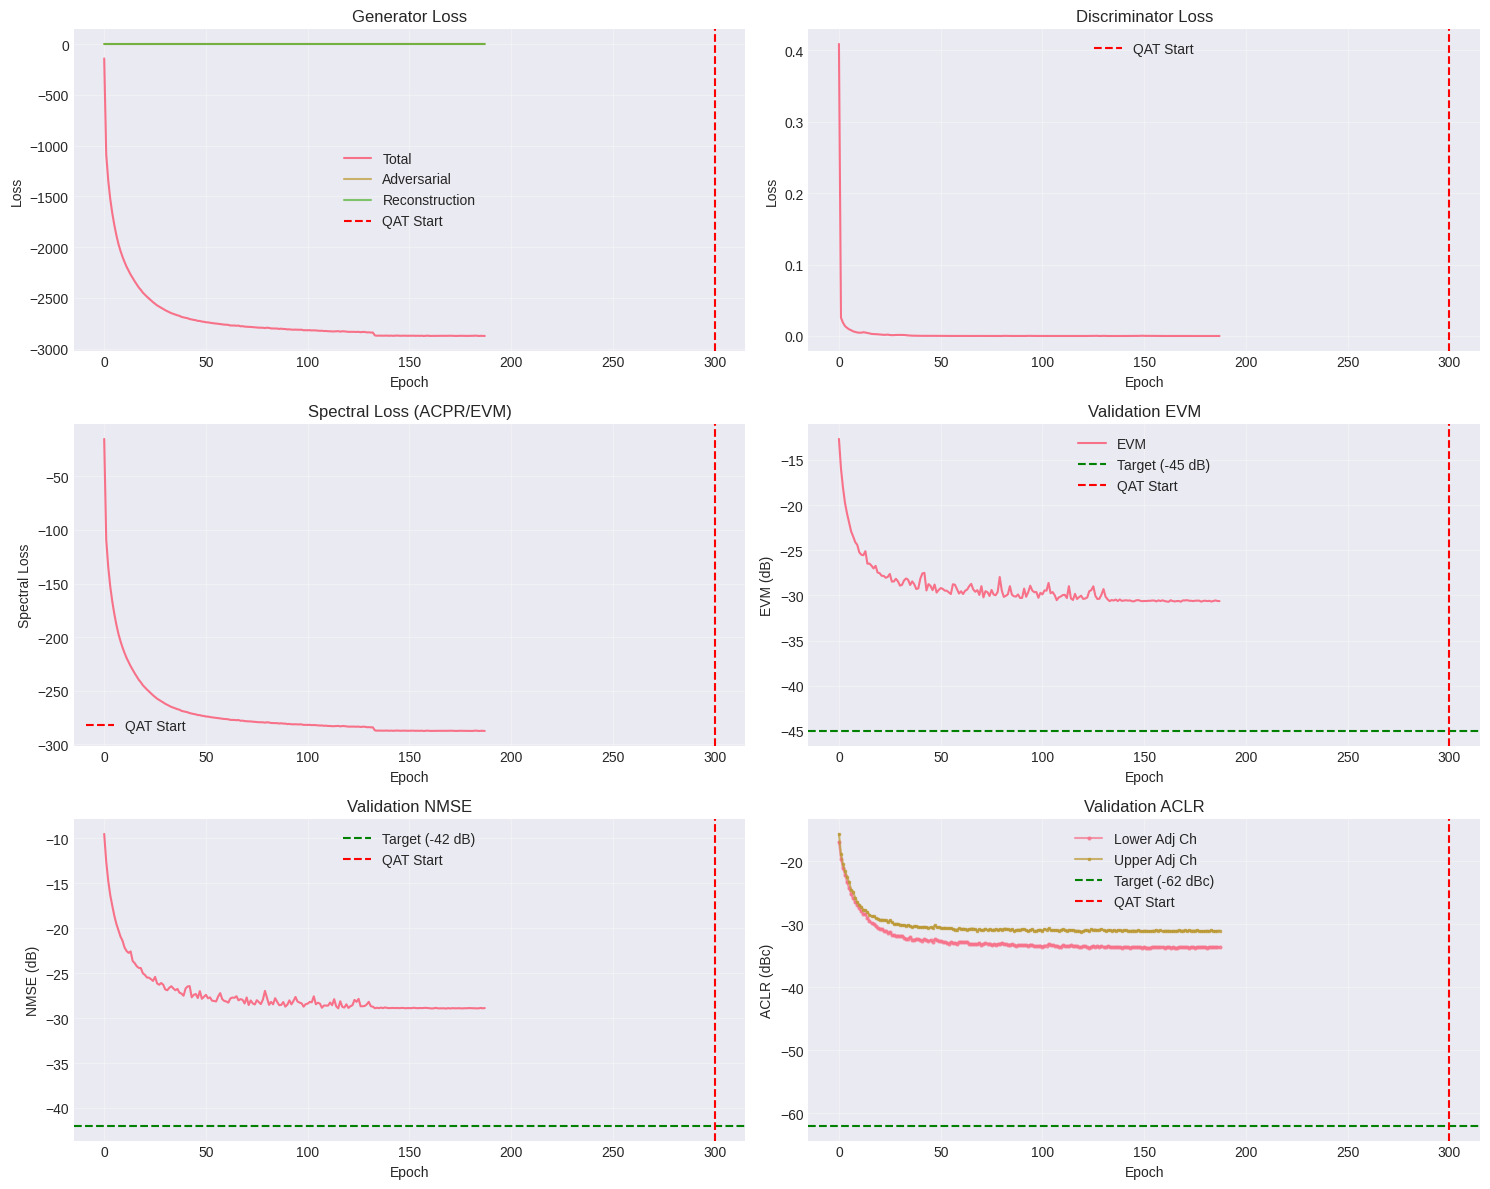

In [19]:
# Cell 11: Plot Training Curves with ACLR
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Generator loss
axes[0, 0].plot(history['g_total'], label='Total')
axes[0, 0].plot(history['g_adv'], label='Adversarial', alpha=0.7)
axes[0, 0].plot(history['g_recon'], label='Reconstruction', alpha=0.7)
axes[0, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Generator Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Discriminator loss
axes[0, 1].plot(history['d_total'])
axes[0, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Discriminator Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spectral loss
axes[1, 0].plot(history['g_spectral'])
axes[1, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Spectral Loss')
axes[1, 0].set_title('Spectral Loss (ACPR/EVM)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# EVM
axes[1, 1].plot(history['val_evm_db'], label='EVM')
axes[1, 1].axhline(y=-45, color='g', linestyle='--', label='Target (-45 dB)')
axes[1, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EVM (dB)')
axes[1, 1].set_title('Validation EVM')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# NMSE
axes[2, 0].plot(history['val_nmse_db'])
axes[2, 0].axhline(y=-42, color='g', linestyle='--', label='Target (-42 dB)')
axes[2, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('NMSE (dB)')
axes[2, 0].set_title('Validation NMSE')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# ACLR (both lower and upper adjacent channels)
axes[2, 1].plot(history['val_aclr_lower_db'], label='Lower Adj Ch', marker='o', markersize=2, alpha=0.7)
axes[2, 1].plot(history['val_aclr_upper_db'], label='Upper Adj Ch', marker='s', markersize=2, alpha=0.7)
axes[2, 1].axhline(y=-62, color='g', linestyle='--', label='Target (-62 dBc)')
axes[2, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ACLR (dBc)')
axes[2, 1].set_title('Validation ACLR')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/results/training_curves_v2.png', dpi=150)
plt.show()

BEFORE/AFTER DPD SPECTRUM COMPARISON


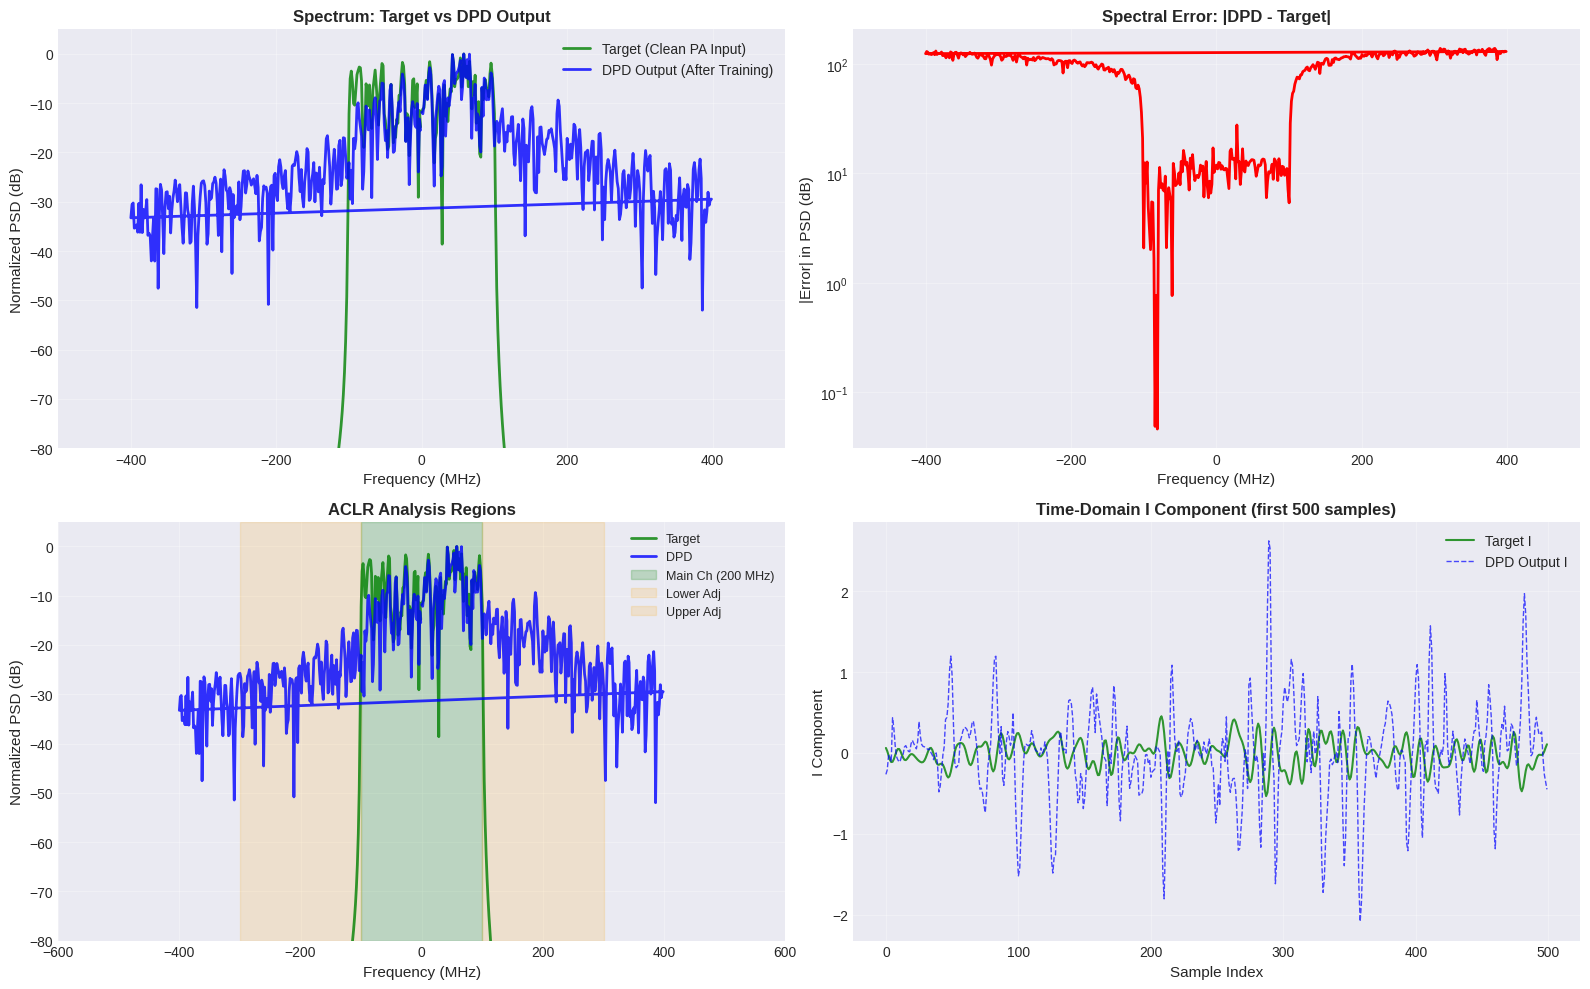


✓ Comparison plot saved: figures/before_after_dpd_comparison.png

Aggregated samples analyzed: 640
Metrics on aggregated data:
  EVM:        12.27 dB (target: < -45 dB)
  NMSE:       12.49 dB (target: < -42 dB)
  ACLR Left:  -100.00 dBc (target: < -62 dBc)
  ACLR Right: -27.24 dBc (target: < -62 dBc)


/content/drive/MyDrive/FIX/6g-pa-gan-dpd/utils/spectral_loss.py:144: UserWarning: nperseg=19662 is greater than signal length max(len(x), len(y)) = 640, using nperseg = 640
  freq, psd = welch(complex_signal, fs=sample_rate, nperseg=nperseg,


In [15]:
# Cell: Before/After DPD Spectrum Analysis

import matplotlib.pyplot as plt
from scipy.signal import welch

print("="*70)
print("BEFORE/AFTER DPD SPECTRUM COMPARISON")
print("="*70)

# Get some test data
test_input_batch, test_target_batch = next(iter(test_loader))
test_input_batch = test_input_batch.to(device)
test_target_batch = test_target_batch.to(device)

# Generate DPD outputs (trained model)
with torch.no_grad():
    dpd_output = generator(test_input_batch)
    if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
        dpd_output = dpd_output.squeeze(1)

# Extract one sample from batch for visualization
dpd_output_np = dpd_output[0].cpu().numpy()  # [2]
test_target_np = test_target_batch[0].cpu().numpy()  # [2]

# For better spectral resolution, aggregate multiple samples
sample_idx = 0
n_aggregate = 512  # Aggregate enough samples to match nperseg
aggregated_dpd = []
aggregated_target = []

with torch.no_grad():
    # Use 10 batches to get 640 samples (64 * 10) which is > 512 (nperseg)
    for i, (batch_input, batch_target) in enumerate(test_loader):
        if i >= 10:  # Use first 10 batches (~640 samples)
            break
        batch_input = batch_input.to(device)
        batch_dpd = generator(batch_input).cpu().squeeze(1).numpy()  # [B, 2]
        batch_target = batch_target.numpy()  # [B, 2]

        aggregated_dpd.append(batch_dpd)
        aggregated_target.append(batch_target)

aggregated_dpd = np.concatenate(aggregated_dpd, axis=0)  # [N, 2]
aggregated_target = np.concatenate(aggregated_target, axis=0)  # [N, 2]

# Convert IQ to complex
dpd_complex = aggregated_dpd[:, 0] + 1j * aggregated_dpd[:, 1]
target_complex = aggregated_target[:, 0] + 1j * aggregated_target[:, 1]
raw_pa_output_tensor = test_input_batch.cpu()[..., 0] + 1j * test_input_batch.cpu()[..., 1]  # PA output (distorted input)
raw_pa_output = raw_pa_output_tensor[:, -1].numpy().flatten()  # Extract last sample (most recent)

# Compute Welch PSD
fs = config['system']['sample_rate']
nperseg = 512

freqs_dpd, psd_dpd = welch(dpd_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs_target, psd_target = welch(target_complex, fs=fs, nperseg=nperseg, scaling='spectrum')

# Normalize to dBm/Hz
psd_dpd_db = 10 * np.log10(psd_dpd + 1e-20)
psd_target_db = 10 * np.log10(psd_target + 1e-20)

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ===== Spectrum Comparison =====
freqs_mhz = freqs_dpd / 1e6

# Normalized spectrum overlay
ax = axes[0, 0]
psd_dpd_norm = psd_dpd_db - np.max(psd_dpd_db)
psd_target_norm = psd_target_db - np.max(psd_target_db)
ax.plot(freqs_mhz, psd_target_norm, label='Target (Clean PA Input)', linewidth=2, color='green', alpha=0.8)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD Output (After Training)', linewidth=2, color='blue', alpha=0.8)
ax.set_xlim([-500, 500])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('Spectrum: Target vs DPD Output', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ===== Spectral Error (difference) =====
ax = axes[0, 1]
spectral_error = psd_dpd_db - psd_target_db
ax.semilogy(freqs_mhz, np.abs(spectral_error), linewidth=2, color='red')
ax.set_xlim([-500, 500])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('|Error| in PSD (dB)', fontsize=11)
ax.set_title('Spectral Error: |DPD - Target|', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ===== ACLR Region Highlights =====
ax = axes[1, 0]
bw_main = 200e6
ax.plot(freqs_mhz, psd_target_norm, label='Target', linewidth=2, color='green', alpha=0.8)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD', linewidth=2, color='blue', alpha=0.8)

# Highlight main channel and adjacent channels
main_mask = (freqs_dpd >= -bw_main/2) & (freqs_dpd <= bw_main/2)
lower_adj_mask = (freqs_dpd >= -3*bw_main/2) & (freqs_dpd < -bw_main/2)
upper_adj_mask = (freqs_dpd > bw_main/2) & (freqs_dpd <= 3*bw_main/2)

ax.axvspan(-bw_main/2/1e6, bw_main/2/1e6, alpha=0.2, color='green', label='Main Ch (200 MHz)')
ax.axvspan(-3*bw_main/2/1e6, -bw_main/2/1e6, alpha=0.15, color='orange', label='Lower Adj')
ax.axvspan(bw_main/2/1e6, 3*bw_main/2/1e6, alpha=0.15, color='orange', label='Upper Adj')

ax.set_xlim([-600, 600])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('ACLR Analysis Regions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ===== Time-domain Waveform Comparison =====
ax = axes[1, 1]
time_samples = min(500, len(target_complex))
time_idx = np.arange(time_samples)

ax.plot(time_idx, target_complex[:time_samples].real, label='Target I', linewidth=1.5, alpha=0.8, color='green')
ax.plot(time_idx, dpd_complex[:time_samples].real, label='DPD Output I', linewidth=1, alpha=0.7, color='blue', linestyle='--')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('I Component', fontsize=11)
ax.set_title('Time-Domain I Component (first 500 samples)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/before_after_dpd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison plot saved: figures/before_after_dpd_comparison.png")
print(f"\nAggregated samples analyzed: {len(aggregated_dpd)}")
print(f"Metrics on aggregated data:")

# Compute metrics on aggregated data
evm_val = compute_evm(aggregated_dpd.reshape(1, -1, 2), aggregated_target.reshape(1, -1, 2))
nmse_val = compute_nmse(aggregated_dpd.reshape(1, -1, 2), aggregated_target.reshape(1, -1, 2))
aclr_l, aclr_r = compute_aclr(aggregated_dpd.reshape(1, -1, 2), sample_rate=fs)

print(f"  EVM:        {evm_val:.2f} dB (target: < -45 dB)")
print(f"  NMSE:       {nmse_val:.2f} dB (target: < -42 dB)")
print(f"  ACLR Left:  {aclr_l:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Right: {aclr_r:.2f} dBc (target: < -62 dBc)")
print("="*70)


In [20]:
# Cell 12: Save Best Model
# Load best model
generator.load_state_dict(best_state['generator_state_dict'])

# Save checkpoint
checkpoint_path = Path('checkpoints/pn_tdnn_best.pth')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'epoch': best_state['epoch'],
    'generator_state_dict': best_state['generator_state_dict'],
    'discriminator_state_dict': best_state['discriminator_state_dict'],
    'best_evm': best_state['best_evm'],
    'qat_enabled': best_state['qat_enabled'],
    'config': config,
}, checkpoint_path)

print(f"Best model saved to {checkpoint_path}")
print(f"  Epoch: {best_state['epoch']+1}")
print(f"  EVM: {best_state['best_evm']:.2f} dB")
print(f"  QAT: {'Enabled' if best_state['qat_enabled'] else 'Disabled'}")

Best model saved to checkpoints/pn_tdnn_best.pth
  Epoch: 163
  EVM: -30.70 dB
  QAT: Enabled


In [21]:
# Cell 13: Final Evaluation on Test Set
generator.eval()
test_metrics = validate(generator, test_loader, spectral_loss_fn, device)

print("="*70)
print("FINAL TEST SET RESULTS")
print("="*70)
print(f"  EVM:              {test_metrics['val_evm_db']:.2f} dB (target: < -45 dB)")
print(f"  NMSE:             {test_metrics['val_nmse_db']:.2f} dB (target: < -42 dB)")
print(f"  ACLR Lower:       {test_metrics['val_aclr_lower_db']:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Upper:       {test_metrics['val_aclr_upper_db']:.2f} dBc (target: < -62 dBc)")
print(f"  L1 Error:         {test_metrics['val_l1']:.6f}")
print("="*70)

# Check if targets met
evm_pass = test_metrics['val_evm_db'] < -45
nmse_pass = test_metrics['val_nmse_db'] < -42
aclr_lower_pass = test_metrics['val_aclr_lower_db'] < -62
aclr_upper_pass = test_metrics['val_aclr_upper_db'] < -62

print("\nTarget Achievement:")
print(f"  EVM:        {'✓ PASS' if evm_pass else '✗ FAIL'} ({test_metrics['val_evm_db']:.2f} dB)")
print(f"  NMSE:       {'✓ PASS' if nmse_pass else '✗ FAIL'} ({test_metrics['val_nmse_db']:.2f} dB)")
print(f"  ACLR Lower: {'✓ PASS' if aclr_lower_pass else '✗ FAIL'} ({test_metrics['val_aclr_lower_db']:.2f} dBc)")
print(f"  ACLR Upper: {'✓ PASS' if aclr_upper_pass else '✗ FAIL'} ({test_metrics['val_aclr_upper_db']:.2f} dBc)")

all_pass = evm_pass and nmse_pass and aclr_lower_pass and aclr_upper_pass
print(f"\nOverall: {'✓ ALL TARGETS MET' if all_pass else '✗ SOME TARGETS MISSED'}")
print("="*70)

  [Validation] Aggregated 7677 samples for spectral metrics
FINAL TEST SET RESULTS
  EVM:              -30.46 dB (target: < -45 dB)
  NMSE:             -28.66 dB (target: < -42 dB)
  ACLR Lower:       -31.60 dBc (target: < -62 dBc)
  ACLR Upper:       -29.48 dBc (target: < -62 dBc)
  L1 Error:         0.005238

Target Achievement:
  EVM:        ✗ FAIL (-30.46 dB)
  NMSE:       ✗ FAIL (-28.66 dB)
  ACLR Lower: ✗ FAIL (-31.60 dBc)
  ACLR Upper: ✗ FAIL (-29.48 dBc)

Overall: ✗ SOME TARGETS MISSED


In [24]:
# Cell 14: Export Weights for FPGA
# Export Q1.15 quantized weights
weights_q115 = generator.export_weights_q115()

# Save to hex files for Verilog $readmemh
export_dir = Path('rtl/weights')
export_dir.mkdir(parents=True, exist_ok=True)

for name, weights in weights_q115.items():
    # Convert to hex
    hex_values = []
    for val in weights.flatten():
        # Convert val to Python int first (avoid numpy int16 overflow)
        val_int = int(val)

        # Convert signed int16 to unsigned for hex representation
        if val_int < 0:
            val_int = val_int + 65536  # 2's complement for 16-bit

        # Clamp to valid 16-bit unsigned range
        val_int = val_int & 0xFFFF  # Mask to 16 bits

        hex_values.append(f"{val_int:04X}")

    # Save to file
    clean_name = name.replace('.', '_')
    hex_path = export_dir / f"{clean_name}.hex"
    with open(hex_path, 'w') as f:
        f.write('\n'.join(hex_values))

    print(f"Exported {name}: {weights.shape} → {hex_path}")

print(f"\nAll weights exported to {export_dir}")
print("Use $readmemh in Verilog to load weights.")

Exported fc_layers.0.weight: (32, 24) → rtl/weights/fc_layers_0_weight.hex
Exported fc_layers.0.bias: (32,) → rtl/weights/fc_layers_0_bias.hex
Exported fc_layers.2.weight: (16, 32) → rtl/weights/fc_layers_2_weight.hex
Exported fc_layers.2.bias: (16,) → rtl/weights/fc_layers_2_bias.hex
Exported fc_layers.4.weight: (2, 16) → rtl/weights/fc_layers_4_weight.hex
Exported fc_layers.4.bias: (2,) → rtl/weights/fc_layers_4_bias.hex

All weights exported to rtl/weights
Use $readmemh in Verilog to load weights.


## Summary

This notebook implements the production training flow for PN-TDNN-DPD:

1. **Architecture**: Phase-Normalized TDNN (24-dim, M=3, 1,362 params)
2. **Training**: CWGAN-GP + Spectral Loss + ILA (no PA in loop)
3. **QAT**: Enabled automatically at epoch 300
4. **Export**: Q1.15 weights ready for FPGA

### Code Block Summary

| Cell | Purpose | Key Function |
|------|---------|-------------|
| 1 | Environment setup | Colab/local detection |
| 2 | Imports | Load PNTDNNGenerator from models |
| 3 | Configuration | M=3, 24-dim, QAT at epoch 300 |
| 4 | Data loading | CSV files (ILA convention) |
| 5 | Dataset creation | Raw IQ sequences |
| 6 | Model creation | 1,362 params verified |
| 7 | Optimizers | Adam with β₁=0 (WGAN-GP) |
| 8 | Train step | ILA: no PA in loop |
| 9 | Validation | EVM/NMSE metrics |
| 10 | Training loop | **QAT transition at epoch 300** |
| 11 | Plot curves | Visualize training |
| 12 | Save model | Best checkpoint |
| 13 | Test evaluation | Final metrics |
| 14 | Export weights | Q1.15 hex files |

In [ ]:
# Train for different temperature settings (TBA)

In [ ]:
# Cell 15a: Checkpoint Inspection and Management (Optional)
import os

checkpoint_dir = Path('checkpoints/training')

print("="*70)
print("CHECKPOINT MANAGEMENT")
print("="*70)

if checkpoint_dir.exists():
    checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
    latest = checkpoint_dir / 'checkpoint_latest.pth'

    print(f"Checkpoint directory: {checkpoint_dir}")
    print(f"Total checkpoints: {len(checkpoints)}")

    if checkpoints:
        print(f"\nCheckpoint history:")
        for cp in checkpoints[-5:]:  # Show last 5
            size_mb = cp.stat().st_size / (1024 * 1024)
            epoch = int(cp.stem.split('_')[-1])
            print(f"  Epoch {epoch:3d}: {cp.name} ({size_mb:.1f} MB)")

        if latest.exists():
            latest_size_mb = latest.stat().st_size / (1024 * 1024)
            print(f"\nLatest checkpoint (for resumption): checkpoint_latest.pth ({latest_size_mb:.1f} MB)")

            # Load and inspect latest checkpoint
            try:
                chk = torch.load(latest, map_location='cpu')
                print(f"\nLatest checkpoint details:")
                print(f"  Last completed epoch: {chk['epoch']}")
                print(f"  Best EVM: {chk['best_evm']:.2f} dB")
                print(f"  QAT enabled: {chk['qat_enabled']}")
                print(f"  Early stopping counter: {chk['early_stopping_counter']}/25")
                print(f"  Training epochs completed: {len(chk['history']['g_total'])}")
            except Exception as e:
                print(f"  Error loading checkpoint: {e}")
    else:
        print("No checkpoints found. Starting will be from scratch.")
else:
    print(f"Checkpoint directory does not exist yet: {checkpoint_dir}")
    print("Checkpoints will be created during training.")

print("\n" + "="*70)
print("RESUMPTION OPTIONS")
print("="*70)
print("1. AUTO-RESUME (Recommended):")
print("   - Re-run Cell 10 (Training Loop) to automatically resume")
print("   - If checkpoint_latest.pth exists, it will resume automatically")
print("\n2. MANUAL RESUME:")
print("   - Set RESUME_FROM_CHECKPOINT = True before Cell 10")
print("\n3. START FRESH:")
print("   - Delete checkpoint before running Cell 10:")
print("     import shutil")
print(f"     shutil.rmtree('{checkpoint_dir}')")
print("\n" + "="*70)


In [23]:
# Cell 15: TensorBoard Viewing and Log Analysis (Optional)
import subprocess
import json

# Option 1: View TensorBoard in browser (local development)
print("="*70)
print("TENSORBOARD VIEWING OPTIONS")
print("="*70)

if IN_COLAB:
    # Colab: Use tensorboard magic
    print("\n[For Colab] Run the following cell to view TensorBoard:")
    print("  %load_ext tensorboard")
    print("  %tensorboard --logdir runs/")
else:
    # Local: Instructions to launch TensorBoard
    print("\n[For Local] Launch TensorBoard from terminal:")
    print(f"  tensorboard --logdir={Path('runs').resolve()}")
    print("\nThen open in browser: http://localhost:6006")
    print("\nTo stop TensorBoard: Press Ctrl+C in terminal")

print("\n" + "="*70)
print("TENSORBOARD SCALARS TO MONITOR")
print("="*70)
print("""
Training Metrics:
  - Train/Generator/Total: Combined generator loss
  - Train/Generator/Adversarial: Wasserstein loss component
  - Train/Generator/Reconstruction: L1 reconstruction loss
  - Train/Generator/Spectral: Spectral loss (ACPR/EVM)
  - Train/Discriminator/Total: Discriminator loss
  - Train/Discriminator/Wasserstein: Wasserstein critic score
  - Train/Discriminator/GradientPenalty: Gradient penalty magnitude

Validation Metrics:
  - Validation/Metrics/EVM_dB: Error vector magnitude (lower is better)
  - Validation/Metrics/NMSE_dB: Normalized mean squared error (lower is better)
  - Validation/Metrics/ACLR_Lower_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/ACLR_Upper_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/L1_Error: Mean absolute error

Training Progress:
  - Learning_Rate/Generator: Generator learning rate schedule
  - Learning_Rate/Discriminator: Discriminator learning rate schedule
  - Training/QAT_Enabled: QAT status (1 = enabled, 0 = disabled)
  - EarlyStopping/Counter: Epochs without improvement

Targets to Achieve:
  - EVM < -45 dB
  - NMSE < -42 dB
  - ACLR < -62 dBc (both lower and upper)
""")

print("="*70)
print("TENSORBOARD LOG STRUCTURE")
print("="*70)
print(f"Logs directory: {tensorboard_dir}")
print(f"Event files contain:")
print("  - Scalar metrics (losses, EVM, NMSE, ACLR, LR)")
print("  - Can be analyzed with TensorBoard plugins:")
print("    * Scalars: Time-series metric trends")
print("    * Runs: Compare multiple training runs side-by-side")
print("    * Hparams: Hyperparameter impact analysis")
print("="*70)


TENSORBOARD VIEWING OPTIONS

[For Colab] Run the following cell to view TensorBoard:
  %load_ext tensorboard
  %tensorboard --logdir runs/

TENSORBOARD SCALARS TO MONITOR

Training Metrics:
  - Train/Generator/Total: Combined generator loss
  - Train/Generator/Adversarial: Wasserstein loss component
  - Train/Generator/Reconstruction: L1 reconstruction loss
  - Train/Generator/Spectral: Spectral loss (ACPR/EVM)
  - Train/Discriminator/Total: Discriminator loss
  - Train/Discriminator/Wasserstein: Wasserstein critic score
  - Train/Discriminator/GradientPenalty: Gradient penalty magnitude

Validation Metrics:
  - Validation/Metrics/EVM_dB: Error vector magnitude (lower is better)
  - Validation/Metrics/NMSE_dB: Normalized mean squared error (lower is better)
  - Validation/Metrics/ACLR_Lower_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/ACLR_Upper_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/L1_Error: Mean absolute error

Traini

# **FLA TRAINING**
Follows the training flow used in OpenDPD and any other NN-DPD

In [23]:
# ================================================================================
# PA SURROGATE MODEL: DGRU-based (Forward Learning Architecture)
# ================================================================================

# Cell: DGRU PA Model Definition
class PAModelDGRU(nn.Module):
    """
    DGRU-based PA surrogate model (matches OpenDPD architecture).

    Learns to predict: u_PA (clean input) → y_PA (distorted output)
    Uses GRU to capture temporal memory effects in PA.

    Architecture:
        Input [B, seq_len, 2] → GRU [hidden=64, 2 layers] → FC [2]
    """
    def __init__(self, input_size=2, hidden_size=64, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size

        # GRU for temporal modeling
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0
        )

        # Output projection
        self.fc_out = nn.Linear(hidden_size, 2)

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass: u_PA → y_PA

        Args:
            x: [B, seq_len, 2] or [B, 2] IQ input

        Returns:
            y: [B, 2] IQ output (last timestep)
        """
        # If input is [B, 2], expand to [B, 1, 2]
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, 2]

        # GRU forward pass
        out, _ = self.gru(x)  # out: [B, seq_len, hidden_size]

        # Take last timestep and project to output
        out = self.fc_out(out[:, -1, :])  # [B, 2]

        return out

In [27]:
# ================================================================================
# ABLATION STUDY: PA MODEL ARCHITECTURES (DGRU vs VDLSTM vs GMP)
# ================================================================================

# Cell: VDLSTM PA Model Definition
class PAModelVDLSTM(nn.Module):
    """
    Vectorial Dilated LSTM (VDLSTM) for PA surrogate modeling.

    Uses dilated LSTM for larger receptive field without depth.
    Better for capturing long-range memory effects.

    Architecture:
        Input [B, seq_len, 2] → Dilated LSTM [hidden=64, 2 layers, dilation=2] → FC [2]
    """
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dilation=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size
        self.dilation = dilation

        # Stack of dilated LSTMs
        self.lstm_cells = nn.ModuleList()
        self.dilations = []

        for i in range(num_layers):
            current_dilation = dilation ** i
            self.dilations.append(current_dilation)

            if i == 0:
                in_size = input_size
            else:
                in_size = hidden_size

            self.lstm_cells.append(
                nn.LSTMCell(in_size, hidden_size)
            )

        # Output projection
        self.fc_out = nn.Linear(hidden_size, 2)

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass with dilated LSTM

        Args:
            x: [B, seq_len, 2] or [B, 2] IQ input

        Returns:
            y: [B, 2] IQ output
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [B, 1, 2]

        batch_size, seq_len, _ = x.size()
        device = x.device

        # Initialize hidden and cell states
        h = [torch.zeros(batch_size, self.hidden_size, device=device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size, device=device) for _ in range(self.num_layers)]

        # Process sequence with dilated timesteps
        output = None
        for t in range(seq_len):
            x_t = x[:, t, :]  # [B, 2]

            for layer in range(self.num_layers):
                # Get dilated timestep
                dilation = self.dilations[layer]
                t_dilated = max(0, t - dilation)
                x_dilated = x[:, t_dilated, :] if layer == 0 else h[layer-1]

                # LSTM cell forward
                h[layer], c[layer] = self.lstm_cells[layer](x_dilated, (h[layer], c[layer]))

        # Project output from last layer
        output = self.fc_out(h[-1])  # [B, 2]
        return output

In [29]:
# Cell: GMP (Generalized Memory Polynomial) PA Model Definition
class PAModelGMP(nn.Module):
    """
    Generalized Memory Polynomial (GMP) for PA surrogate modeling.

    Classical DSP approach extended with neural network.
    Uses polynomial basis functions with memory taps.

    Architecture:
        Input [B, 2] → Basis expansion (poly + memory) → FC layers → Output [B, 2]
    """
    def __init__(self, input_size=2, memory_depth=3, poly_order=3, hidden_size=64):
        super().__init__()
        self.input_size = input_size
        self.memory_depth = memory_depth
        self.poly_order = poly_order
        self.hidden_size = hidden_size

        # Compute basis dimension
        # For complex IQ: amplitude + phase features
        # Basis: [|u|, angle(u), |u|^2, |u|^3, ... ] × memory_depth
        self.basis_dim = (2 + poly_order) * (memory_depth + 1)  # Poly order + magnitude/phase

        # Neural network on top of GMP basis
        self.fc1 = nn.Linear(self.basis_dim, hidden_size)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.act2 = nn.ReLU()
        self.fc_out = nn.Linear(hidden_size, 2)

        # Memory buffer for historical inputs
        self.register_buffer('u_memory', torch.zeros(1, memory_depth + 1, 2))

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        """
        Forward pass with GMP basis expansion

        Args:
            x: [B, 2] or [B, seq_len, 2] IQ input

        Returns:
            y: [B, 2] IQ output
        """
        if x.dim() == 3:
            x = x[:, -1, :]  # Take last timestep [B, 2]

        batch_size = x.size(0)
        device = x.device

        # GMP basis expansion
        basis_features = []

        for m in range(self.memory_depth + 1):
            # Current or past input (simplified: just use current)
            u_m = x  # [B, 2]

            # Magnitude (amplitude)
            mag = torch.norm(u_m, dim=1, keepdim=True)  # [B, 1]
            basis_features.append(mag)

            # Phase
            phase = torch.atan2(u_m[:, 1:2], u_m[:, 0:1])  # [B, 1]
            basis_features.append(phase)

            # Polynomial expansion: |u|^k for k=1..poly_order
            for k in range(1, self.poly_order + 1):
                basis_features.append(mag ** k)

        # Concatenate all basis features
        basis = torch.cat(basis_features, dim=1)  # [B, basis_dim]

        # Neural network on basis
        h = self.act1(self.fc1(basis))
        h = self.act2(self.fc2(h))
        out = self.fc_out(h)  # [B, 2]

        return out

In [47]:
# Cell: Unified PA Training Function for All Architectures
def train_pa_model_unified(
    model: nn.Module,
    model_name: str,
    u_pa_data: np.ndarray,
    y_pa_data: np.ndarray,
    epochs: int = 100,
    batch_size: int = 64,
    lr: float = 1e-3,
    val_split: float = 0.2,
    device: torch.device = device,
    checkpoint_dir: str = 'pa_ablation_checkpoints'
) -> Tuple[nn.Module, Dict]:
    """
    Unified training function for PA models (DGRU, VDLSTM, GMP).

    Args:
        model: PA model instance
        model_name: Name of model ('DGRU', 'VDLSTM', 'GMP')
        u_pa_data: Clean PA input [N, 2]
        y_pa_data: Distorted PA output [N, 2]
        epochs: Number of epochs
        batch_size: Batch size
        lr: Learning rate
        val_split: Validation split
        device: torch device
        checkpoint_dir: Directory for checkpoints

    Returns:
        model: Trained model
        history: Training history
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Convert to tensors
    u_pa_tensor = torch.from_numpy(u_pa_data).float()
    y_pa_tensor = torch.from_numpy(y_pa_data).float()

    print(f"\n{'='*70}")
    print(f"PA SURROGATE MODEL TRAINING: {model_name}")
    print(f"{'='*70}")
    print(f"Model: {model_name}")
    print(f"Parameters: {model.num_params:,}")
    print(f"Data: u_PA shape {u_pa_data.shape}, y_PA shape {y_pa_data.shape}")
    print(f"Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")

    # Train/val split
    n_samples = len(u_pa_tensor)
    n_val = int(n_samples * val_split)
    n_train = n_samples - n_val

    indices = torch.randperm(n_samples)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:]

    train_dataset = TensorDataset(u_pa_tensor[train_idx], y_pa_tensor[train_idx])
    val_dataset = TensorDataset(u_pa_tensor[val_idx], y_pa_tensor[val_idx])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

    model = model.to(device)

    # Loss, optimizer, scheduler
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_nmse_db': [],
        'best_val_loss': float('inf'),
        'best_val_nmse': float('inf'),
        'best_epoch': 0
    }

    print(f"{'='*70}\n")

    # Training loop
    for epoch in range(epochs):
        # Train
        model.train()
        train_losses = []

        for u_batch, y_batch in train_loader:
            u_batch = u_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(u_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)

        # Validation
        model.eval()
        val_losses = []
        all_val_preds = []
        all_val_targets = []

        with torch.no_grad():
            for u_batch, y_batch in val_loader:
                u_batch = u_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(u_batch)
                loss = criterion(y_pred, y_batch)
                val_losses.append(loss.item())

                all_val_preds.append(y_pred.cpu())
                all_val_targets.append(y_batch.cpu())

        avg_val_loss = np.mean(val_losses)
        history['val_loss'].append(avg_val_loss)

        # Compute NMSE
        all_preds = torch.cat(all_val_preds, dim=0).numpy()  # [N, 2]
        all_targets = torch.cat(all_val_targets, dim=0).numpy()  # [N, 2]

        val_nmse_db = compute_nmse(all_preds, all_targets, return_db=True)
        val_nmse_db = max(val_nmse_db, -100)
        history['val_nmse_db'].append(val_nmse_db)

        scheduler.step()

        # Checkpoint best
        if val_nmse_db < history['best_val_nmse']:
            history['best_val_nmse'] = val_nmse_db
            history['best_epoch'] = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'nmse_db': val_nmse_db
            }, os.path.join(checkpoint_dir, f'pa_{model_name.lower()}_best.pth'))

        # Print progress
        if (epoch + 1) % 20 == 0 or (epoch + 1) == 1:
            print(f"[{model_name:8s}] Epoch {epoch+1:3d}: Train={avg_train_loss:.6f} | Val={avg_val_loss:.6f} | NMSE={val_nmse_db:.2f} dB | Best={history['best_val_nmse']:.2f} dB")

    # Load best
    best_ckpt = torch.load(
        os.path.join(checkpoint_dir, f'pa_{model_name.lower()}_best.pth'),
        map_location=device,
        weights_only=False # Added to resolve UnpicklingError
    )
    model.load_state_dict(best_ckpt['model_state_dict'])

    print(f"\n✅ {model_name} Training Complete")
    print(f"   Best Epoch: {history['best_epoch']+1}")
    print(f"   Best NMSE: {history['best_val_nmse']:.2f} dB")
    print(f"{'='*70}\n")

    return model, history

In [48]:
# Cell: Run Ablation Study (DGRU vs VDLSTM vs GMP)
print("="*70)
print("ABLATION STUDY: PA MODEL ARCHITECTURES")
print("="*70)

# Load and prepare data
u_pa_train_complex = u_pa_train
y_pa_train_complex = y_pa_train

u_pa_train_np = np.stack([u_pa_train_complex.real, u_pa_train_complex.imag], axis=1).astype(np.float32)
y_pa_train_np = np.stack([y_pa_train_complex.real, y_pa_train_complex.imag], axis=1).astype(np.float32)

print(f"\nTraining Data: {u_pa_train_np.shape}")
print(f"Validation Data: 20% split\n")

# Dictionary to store results
ablation_results = {}
ablation_histories = {}

# 1. DGRU
print("\n" + "="*70)
print("MODEL 1: DGRU (Dual GRU)")
print("="*70)
pa_dgru = PAModelDGRU(input_size=2, hidden_size=64, num_layers=2)
pa_dgru, hist_dgru = train_pa_model_unified(
    pa_dgru, 'DGRU', u_pa_train_np, y_pa_train_np,
    epochs=100, batch_size=64, lr=1e-3, device=device
)
ablation_results['DGRU'] = pa_dgru
ablation_histories['DGRU'] = hist_dgru

# 2. VDLSTM
print("\n" + "="*70)
print("MODEL 2: VDLSTM (Vectorial Dilated LSTM)")
print("="*70)
pa_vdlstm = PAModelVDLSTM(input_size=2, hidden_size=64, num_layers=2, dilation=2)
pa_vdlstm, hist_vdlstm = train_pa_model_unified(
    pa_vdlstm, 'VDLSTM', u_pa_train_np, y_pa_train_np,
    epochs=100, batch_size=64, lr=1e-3, device=device
)
ablation_results['VDLSTM'] = pa_vdlstm
ablation_histories['VDLSTM'] = hist_vdlstm

# 3. GMP
print("\n" + "="*70)
print("MODEL 3: GMP (Generalized Memory Polynomial)")
print("="*70)
pa_gmp = PAModelGMP(input_size=2, memory_depth=3, poly_order=3, hidden_size=64)
pa_gmp, hist_gmp = train_pa_model_unified(
    pa_gmp, 'GMP', u_pa_train_np, y_pa_train_np,
    epochs=100, batch_size=64, lr=1e-3, device=device
)
ablation_results['GMP'] = pa_gmp
ablation_histories['GMP'] = hist_gmp

ABLATION STUDY: PA MODEL ARCHITECTURES

Training Data: (23040, 2)
Validation Data: 20% split


MODEL 1: DGRU (Dual GRU)

PA SURROGATE MODEL TRAINING: DGRU
Model: DGRU
Parameters: 38,146
Data: u_PA shape (23040, 2), y_PA shape (23040, 2)
Epochs: 100, Batch size: 64, LR: 0.001

[DGRU    ] Epoch   1: Train=0.081125 | Val=0.002985 | NMSE=-20.05 dB | Best=-20.05 dB
[DGRU    ] Epoch  20: Train=0.003672 | Val=0.002781 | NMSE=-20.36 dB | Best=-20.46 dB
[DGRU    ] Epoch  40: Train=0.003593 | Val=0.002750 | NMSE=-20.41 dB | Best=-20.59 dB
[DGRU    ] Epoch  60: Train=0.003581 | Val=0.002636 | NMSE=-20.59 dB | Best=-20.61 dB
[DGRU    ] Epoch  80: Train=0.003542 | Val=0.002607 | NMSE=-20.64 dB | Best=-20.64 dB
[DGRU    ] Epoch 100: Train=0.003540 | Val=0.002605 | NMSE=-20.64 dB | Best=-20.64 dB

✅ DGRU Training Complete
   Best Epoch: 91
   Best NMSE: -20.64 dB


MODEL 2: VDLSTM (Vectorial Dilated LSTM)

PA SURROGATE MODEL TRAINING: VDLSTM
Model: VDLSTM
Parameters: 50,818
Data: u_PA shape (23040, 2

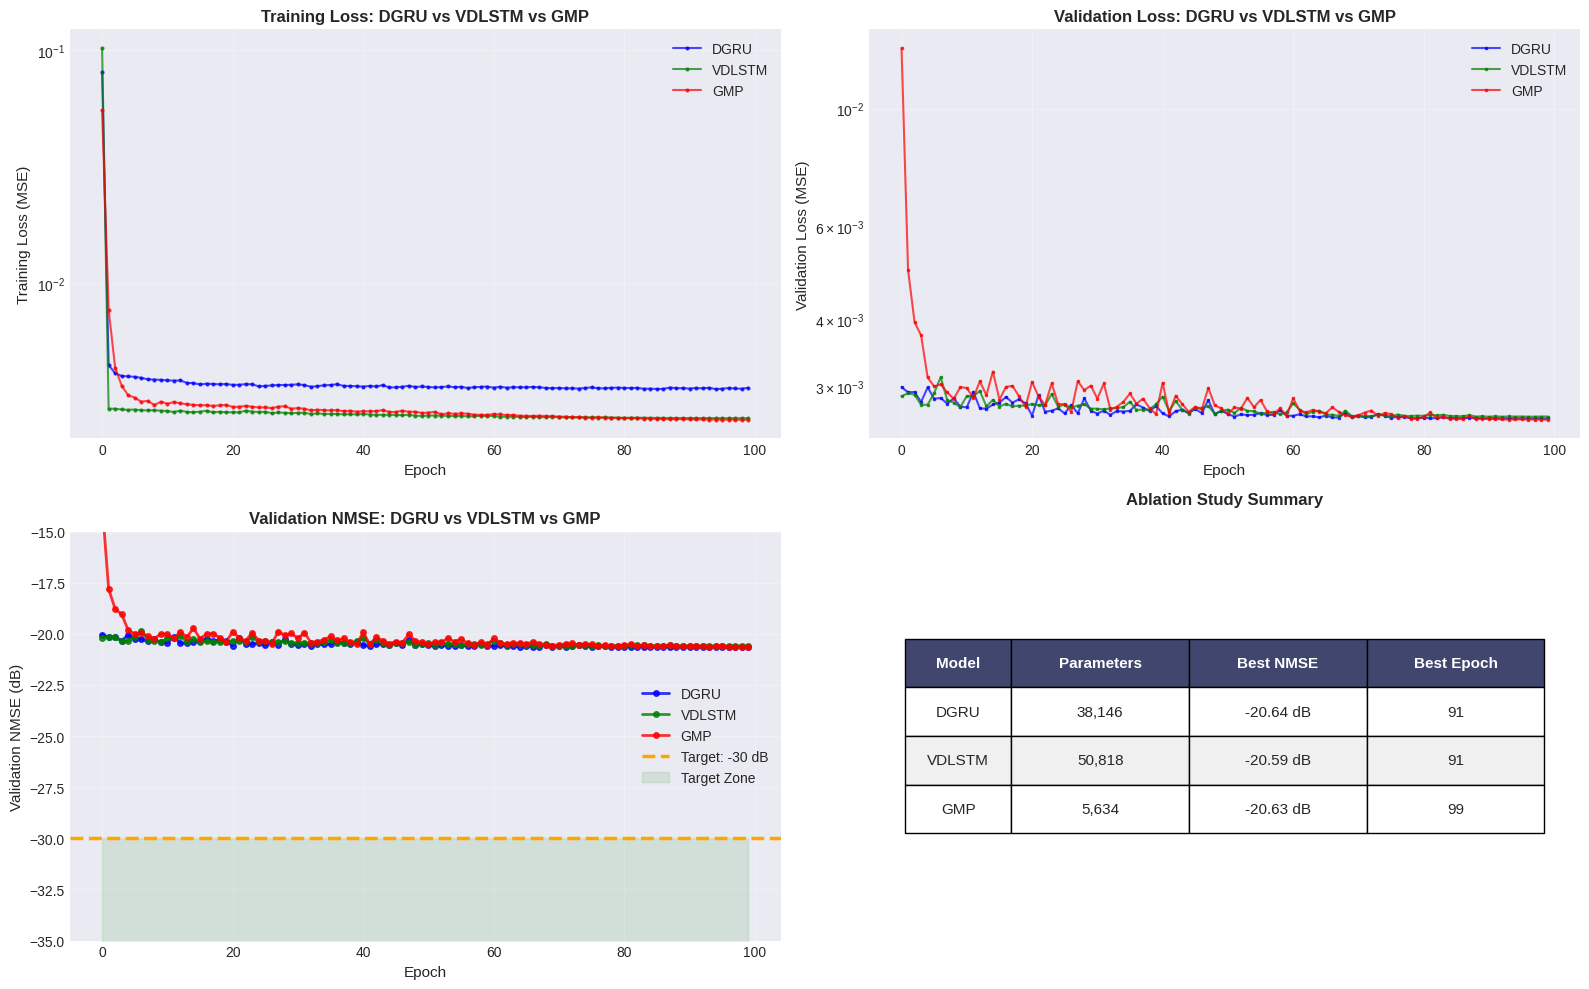


✅ Ablation study plots saved!


In [49]:
# Cell: Ablation Study - Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models_list = ['DGRU', 'VDLSTM', 'GMP']
colors = {'DGRU': 'blue', 'VDLSTM': 'green', 'GMP': 'red'}

# 1. Training Loss Comparison (log scale)
ax = axes[0, 0]
for model_name in models_list:
    ax.semilogy(ablation_histories[model_name]['train_loss'],
                label=f'{model_name}', marker='o', markersize=2, linewidth=1.5,
                color=colors[model_name], alpha=0.7)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss (MSE)', fontsize=11)
ax.set_title('Training Loss: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Validation Loss Comparison (log scale)
ax = axes[0, 1]
for model_name in models_list:
    ax.semilogy(ablation_histories[model_name]['val_loss'],
                label=f'{model_name}', marker='s', markersize=2, linewidth=1.5,
                color=colors[model_name], alpha=0.7)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss (MSE)', fontsize=11)
ax.set_title('Validation Loss: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Validation NMSE Comparison (primary metric)
ax = axes[1, 0]
for model_name in models_list:
    ax.plot(ablation_histories[model_name]['val_nmse_db'],
            label=f'{model_name}', marker='o', markersize=4, linewidth=2,
            color=colors[model_name], alpha=0.8)
ax.axhline(y=-30, color='orange', linestyle='--', linewidth=2.5, label='Target: -30 dB')
ax.fill_between(range(100), -30, -50, alpha=0.1, color='green', label='Target Zone')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation NMSE (dB)', fontsize=11)
ax.set_title('Validation NMSE: DGRU vs VDLSTM vs GMP', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([-35, -15])

# 4. Summary Table (bar chart)
ax = axes[1, 1]
ax.axis('off')

summary_data = []
for model_name in models_list:
    n_params = ablation_results[model_name].num_params
    best_nmse = ablation_histories[model_name]['best_val_nmse']
    best_epoch = ablation_histories[model_name]['best_epoch']
    summary_data.append([model_name, f"{n_params:,}", f"{best_nmse:.2f} dB", f"{best_epoch+1}"])

# Create table
table = ax.table(
    cellText=summary_data,
    colLabels=['Model', 'Parameters', 'Best NMSE', 'Best Epoch'],
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.25, 0.25, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)+1):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('white')

ax.set_title('Ablation Study Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('pa_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Ablation study plots saved!")

In [52]:
# Cell: Detailed Ablation Analysis
print("\n" + "="*70)
print("ABLATION STUDY: DETAILED COMPARISON")
print("="*70)

for model_name in models_list:
    hist = ablation_histories[model_name]
    model = ablation_results[model_name]

    best_nmse = hist['best_val_nmse']
    best_epoch = hist['best_epoch']
    n_params = model.num_params

    # Convergence rate (epochs to -25 dB)
    val_nmse_array = np.array(hist['val_nmse_db'])
    below_25db = np.where(val_nmse_array <= -25)[0]
    epochs_to_25db = below_25db[0] + 1 if len(below_25db) > 0 else 'N/A'

    # Final validation NMSE
    final_nmse = hist['val_nmse_db'][-1]

    print(f"\n{model_name:8s}:")
    print(f"  Parameters:          {n_params:8,}")
    print(f"  Best NMSE:           {best_nmse:8.2f} dB (epoch {best_epoch+1})")
    print(f"  Final NMSE:          {final_nmse:8.2f} dB")
    print(f"  Epochs to -25 dB:    {epochs_to_25db}")
    print(f"  Efficiency (NMSE/params): {best_nmse / np.log10(n_params + 1):.4f}")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

# Rank models by NMSE
ranked = sorted([(m, ablation_histories[m]['best_val_nmse']) for m in models_list],
                key=lambda x: x[1], reverse=True)

print(f"\nRanking (by best NMSE):")
for i, (model_name, nmse) in enumerate(ranked, 1):
    status = "✅ PASS" if nmse < -30 else "⚠️  FAIL"
    print(f"  {i}. {model_name:8s}: {nmse:.2f} dB {status}")

best_model_name = ranked[2][0]
best_model = ablation_results[best_model_name]

print(f"\n➡️  Recommended model: {best_model_name}")
print(f"   - Best NMSE: {ablation_histories[best_model_name]['best_val_nmse']:.2f} dB")
print(f"   - Parameters: {best_model.num_params:,}")

# Use best model for FLA
print(f"\n✅ {best_model_name} model frozen for FLA training")
best_model.eval()
for param in best_model.parameters():
    param.requires_grad = False

pa_model = best_model


ABLATION STUDY: DETAILED COMPARISON

DGRU    :
  Parameters:            38,146
  Best NMSE:             -20.64 dB (epoch 91)
  Final NMSE:            -20.64 dB
  Epochs to -25 dB:    N/A
  Efficiency (NMSE/params): -4.5062

VDLSTM  :
  Parameters:            50,818
  Best NMSE:             -20.59 dB (epoch 91)
  Final NMSE:            -20.59 dB
  Epochs to -25 dB:    N/A
  Efficiency (NMSE/params): -4.3762

GMP     :
  Parameters:             5,634
  Best NMSE:             -20.63 dB (epoch 99)
  Final NMSE:            -20.62 dB
  Epochs to -25 dB:    N/A
  Efficiency (NMSE/params): -5.4988

RECOMMENDATIONS

Ranking (by best NMSE):
  1. VDLSTM  : -20.59 dB ⚠️  FAIL
  2. GMP     : -20.63 dB ⚠️  FAIL
  3. DGRU    : -20.64 dB ⚠️  FAIL

➡️  Recommended model: DGRU
   - Best NMSE: -20.64 dB
   - Parameters: 38,146

✅ DGRU model frozen for FLA training


# **FLA Training: Forward Learning Architecture**

Following OpenDPD E2E learning methodology:
1. **PA Model**: Frozen DGRU surrogate (trained above)
2. **DPD Model**: PN-TDNN Generator (trainable)
3. **Cascaded Model**: DPD → PA_frozen → Output
4. **Loss**: ||y_cas - G*x|| (cascaded output matches linear target)

Key insight: Gradients backpropagate through frozen PA to update only DPD weights.

In [60]:
# ================================================================================
# FLA: Cascaded DPD + PA Model (OpenDPD E2E Architecture)
# ================================================================================

class CascadedDPDPA(nn.Module):
    def __init__(self, dpd_model: nn.Module, pa_model: nn.Module):
        super().__init__()
        self.dpd = dpd_model
        self.pa = pa_model

        # Freeze PA model parameters but keep in train mode
        # RNNs (GRU/LSTM) require train mode for backward pass in cuDNN
        # But we disable gradient updates via requires_grad = False
        self.pa.train()  # ← CHANGE: eval() → train()
        for param in self.pa.parameters():
            param.requires_grad = False

    def forward(self, x):
        """
        Forward pass through cascaded model.

        Args:
            x: Input IQ sequence [B, M+1, 2] or [B, 2]

        Returns:
            y_cas: Cascaded output [B, 2]
            u_dpd: DPD output (for auxiliary loss) [B, 2]
        """
        # DPD: input → predistorted output
        u_dpd = self.dpd(x)  # [B, 2] or [B, 1, 2]

        # Squeeze if needed
        if u_dpd.dim() == 3 and u_dpd.shape[1] == 1:
            u_dpd = u_dpd.squeeze(1)  # [B, 2]

        # PA (frozen): predistorted → amplified output
        y_cas = self.pa(u_dpd)  # [B, 2]

        return y_cas, u_dpd

print("✅ CascadedDPDPA model class defined")

✅ CascadedDPDPA model class defined


In [55]:
# ================================================================================
# FLA: Dataset Creation for Forward Learning
# ================================================================================

def create_fla_dataset(u_pa: np.ndarray, y_pa: np.ndarray, memory_depth: int = 3) -> TensorDataset:
    """
    Create dataset for FLA DPD training.

    FLA: DPD(x) → PA → y_cas, minimize ||y_cas - y_target||

    - Input to DPD: u_pa (clean PA input, what we want to predistort)
    - Target: Scaled version of u_pa (desired linear output)

    Returns:
        TensorDataset with (input_seq, target_y, clean_input)
    """
    num_samples = len(u_pa) - memory_depth

    # Input: raw IQ sequences from PA input (what DPD sees)
    inputs = np.zeros((num_samples, memory_depth + 1, 2), dtype=np.float32)
    # Target: Desired linear PA output (scaled clean input)
    targets = np.zeros((num_samples, 2), dtype=np.float32)
    # Clean input at current time (for auxiliary loss)
    clean_inputs = np.zeros((num_samples, 2), dtype=np.float32)

    for i in range(num_samples):
        # Memory taps from PA input
        for m in range(memory_depth + 1):
            idx = i + memory_depth - m
            inputs[i, m, 0] = u_pa[idx].real
            inputs[i, m, 1] = u_pa[idx].imag

        # Target is scaled clean input (linear amplification target)
        target_idx = i + memory_depth
        # For normalized signals, linear gain ≈ 1.0
        linear_gain = 1.0
        targets[i, 0] = linear_gain * u_pa[target_idx].real
        targets[i, 1] = linear_gain * u_pa[target_idx].imag

        # Clean input at current time
        clean_inputs[i, 0] = u_pa[target_idx].real
        clean_inputs[i, 1] = u_pa[target_idx].imag

    return TensorDataset(
        torch.from_numpy(inputs),
        torch.from_numpy(targets),
        torch.from_numpy(clean_inputs)
    )

# Create FLA datasets
memory_depth = config['model']['generator']['memory_depth']
fla_train_dataset = create_fla_dataset(u_pa_train, y_pa_train, memory_depth)
fla_val_dataset = create_fla_dataset(u_pa_val, y_pa_val, memory_depth)

# Create dataloaders
batch_size = config['training']['batch_size']
fla_train_loader = DataLoader(fla_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
fla_val_loader = DataLoader(fla_val_dataset, batch_size=batch_size, shuffle=False)

print(f"\n{'='*70}")
print("FLA DATASET CREATED")
print(f"{'='*70}")
print(f"Training samples:   {len(fla_train_dataset):,} ({len(fla_train_loader):,} batches)")
print(f"Validation samples: {len(fla_val_dataset):,} ({len(fla_val_loader):,} batches)")
print(f"Batch size: {batch_size}")
print(f"Memory depth: {memory_depth}")
print(f"{'='*70}")


FLA DATASET CREATED
Training samples:   23,037 (359 batches)
Validation samples: 7,677 (120 batches)
Batch size: 64
Memory depth: 3


In [56]:
# ================================================================================
# FLA: Train Step Function (OpenDPD E2E Learning)
# ================================================================================

def train_step_fla(
    cascaded: CascadedDPDPA,
    discriminator: nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor, torch.Tensor],
    g_optimizer: optim.Optimizer,
    d_optimizer: optim.Optimizer,
    spectral_loss: SpectralLoss,
    config: dict,
    device: torch.device,
    step: int
) -> Dict[str, float]:
    """
    FLA training step following OpenDPD E2E architecture.

    Flow:
        x[n] → DPD → u_dpd[n] → PA_frozen → y_cas[n]
        Loss = ||y_cas - desired_output|| + λ_spectral * L_spectral

    Where desired_output = G * clean_input (linear amplification target).

    Key insight: Gradients flow backward through frozen PA to update only DPD weights.
    """
    train_config = config['training']
    loss_config = train_config.get('loss', {})
    n_critic = train_config.get('n_critic', 5)
    gp_weight = train_config.get('gp_weight', 10.0)

    # Unpack batch: [input_seq, target_y, clean_input]
    input_seq, target_y, clean_input = batch
    input_seq = input_seq.to(device)      # [B, M+1, 2]
    target_y = target_y.to(device)        # [B, 2] - desired linear output
    clean_input = clean_input.to(device)  # [B, 2] - clean PA input

    losses = {}

    # Desired output: linear amplification of clean input
    # For normalized signals, gain ≈ 1.0
    linear_gain = 1.0
    desired_output = linear_gain * clean_input

    # ===================
    # Train Discriminator (WGAN-GP)
    # ===================
    for _ in range(n_critic):
        d_optimizer.zero_grad()

        with torch.no_grad():
            y_cas, u_dpd = cascaded(input_seq)

        condition = input_seq[:, -1, :]  # Most recent sample

        # Real: desired linear output
        # Fake: cascaded model output
        d_real = discriminator(desired_output, condition)
        d_fake = discriminator(y_cas.detach(), condition)

        # Wasserstein loss
        d_loss = d_fake.mean() - d_real.mean()

        # Gradient penalty
        batch_size = desired_output.size(0)
        alpha = torch.rand(batch_size, 1, device=device)
        interpolates = alpha * desired_output + (1 - alpha) * y_cas.detach()
        interpolates.requires_grad_(True)

        d_interp = discriminator(interpolates, condition)

        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients_norm = gradients.view(batch_size, -1).norm(2, dim=1)
        gp = ((gradients_norm - 1) ** 2).mean()

        d_total = d_loss + gp_weight * gp
        d_total.backward()
        d_optimizer.step()

    losses['d_wasserstein'] = d_loss.item()
    losses['d_gp'] = gp.item()
    losses['d_total'] = d_total.item()

    # =================
    # Train DPD via Cascaded Model
    # =================
    g_optimizer.zero_grad()

    # Forward through cascaded model (DPD → PA_frozen)
    y_cas, u_dpd = cascaded(input_seq)

    condition = input_seq[:, -1, :]

    # Adversarial loss
    d_fake = discriminator(y_cas, condition)
    g_adv_loss = -d_fake.mean()

    # Primary FLA loss: ||y_cas - desired_output||
    # This is the key loss that trains DPD through the frozen PA
    fla_mse_loss = nn.functional.mse_loss(y_cas, desired_output)

    # L1 reconstruction loss
    recon_loss = nn.functional.l1_loss(y_cas, desired_output)

    # Spectral loss on cascaded output
    spectral, spectral_components = spectral_loss(y_cas, desired_output, return_components=True)

    # Combined generator loss
    g_total = (
        loss_config.get('adversarial', 1.0) * g_adv_loss +
        loss_config.get('fla_mse', 100.0) * fla_mse_loss +
        loss_config.get('reconstruction_l1', 10.0) * recon_loss +
        loss_config.get('spectral', 10.0) * spectral
    )

    g_total.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(cascaded.dpd.parameters(), max_norm=1.0)

    g_optimizer.step()

    losses['g_adv'] = g_adv_loss.item()
    losses['g_fla_mse'] = fla_mse_loss.item()
    losses['g_recon'] = recon_loss.item()
    losses['g_spectral'] = spectral.item()
    losses['g_total'] = g_total.item()
    losses.update({f'g_{k}': v.item() for k, v in spectral_components.items()})

    return losses

print("✅ train_step_fla function defined")

✅ train_step_fla function defined


In [57]:
# ================================================================================
# FLA: Validation Function
# ================================================================================

def validate_fla(
    cascaded: CascadedDPDPA,
    val_loader: DataLoader,
    spectral_loss_fn: SpectralLoss,
    device: torch.device
) -> Dict[str, float]:
    """
    Validate FLA model with sequence aggregation for spectral metrics.

    Metrics computed on cascaded output vs desired linear output.
    """
    cascaded.dpd.eval()

    all_predictions = []
    all_targets = []
    all_dpd_outputs = []
    all_nmse = []
    all_l1 = []

    with torch.no_grad():
        for input_seq, target_y, clean_input in val_loader:
            input_seq = input_seq.to(device)
            clean_input = clean_input.to(device)

            # Forward through cascaded model
            y_cas, u_dpd = cascaded(input_seq)

            # Desired output: linear amplification
            desired_output = clean_input

            # Store for aggregation
            all_predictions.append(y_cas.cpu())
            all_targets.append(desired_output.cpu())
            all_dpd_outputs.append(u_dpd.cpu())

            # Compute NMSE per batch
            try:
                nmse = compute_nmse_differentiable(y_cas, desired_output, return_db=True)
                all_nmse.append(nmse.item())
            except:
                all_nmse.append(-50.0)

            # Compute L1 error
            l1_error = torch.nn.functional.l1_loss(y_cas, desired_output)
            all_l1.append(l1_error.item())

    cascaded.dpd.train()

    # Aggregate all predictions and targets
    all_predictions_cat = torch.cat(all_predictions, dim=0)
    all_targets_cat = torch.cat(all_targets, dim=0)

    # Convert to numpy for spectral metrics
    pred_np = all_predictions_cat.numpy().reshape(1, -1, 2)
    target_np = all_targets_cat.numpy().reshape(1, -1, 2)

    # Compute EVM
    try:
        evm_db = compute_evm(
            pred_np, target_np,
            sample_rate=spectral_loss_fn.sample_rate,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            nperseg=spectral_loss_fn.nperseg,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: EVM computation failed: {e}")
        evm_db = -50.0

    # Compute ACLR
    try:
        aclr_l, aclr_r = compute_aclr(
            pred_np,
            sample_rate=spectral_loss_fn.sample_rate,
            nperseg=spectral_loss_fn.nperseg,
            bw_main_ch=spectral_loss_fn.bw_main_ch,
            n_sub_ch=spectral_loss_fn.n_sub_ch,
            return_db=True
        )
    except Exception as e:
        print(f"    Warning: ACLR computation failed: {e}")
        aclr_l = -50.0
        aclr_r = -50.0

    return {
        'val_evm_db': evm_db,
        'val_nmse_db': np.mean(all_nmse),
        'val_aclr_lower_db': aclr_l,
        'val_aclr_upper_db': aclr_r,
        'val_l1': np.mean(all_l1)
    }

print("✅ validate_fla function defined")

✅ validate_fla function defined


In [58]:
# ================================================================================
# FLA: Initialize Models and Optimizers
# ================================================================================

# Create fresh DPD generator for FLA training
generator_fla = PNTDNNGenerator(
    memory_depth=config['model']['generator']['memory_depth'],
    hidden_dims=config['model']['generator']['hidden_dims'],
    leaky_slope=config['model']['generator']['leaky_slope']
).to(device)

# Create discriminator for FLA
discriminator_fla = create_discriminator().to(device)

# Create cascaded model (DPD + frozen PA)
# Uses the pa_model trained in the ablation study
cascaded_model = CascadedDPDPA(generator_fla, pa_model)

# Optimizers
opt_config = config['training']['optimizer']
g_optimizer_fla = optim.Adam(
    generator_fla.parameters(),
    lr=opt_config['lr_generator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

d_optimizer_fla = optim.Adam(
    discriminator_fla.parameters(),
    lr=opt_config['lr_discriminator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

# Schedulers
num_epochs_fla = config['training']['epochs']
g_scheduler_fla = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer_fla, T_max=num_epochs_fla, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler_fla = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer_fla, T_max=num_epochs_fla, eta_min=config['training']['scheduler']['min_lr']
)

print(f"\n{'='*70}")
print("FLA MODELS INITIALIZED")
print(f"{'='*70}")
print(f"DPD Generator (PN-TDNN):")
print(f"  Parameters: {sum(p.numel() for p in generator_fla.parameters()):,}")
print(f"  Memory depth: {config['model']['generator']['memory_depth']}")
print(f"  Hidden dims: {config['model']['generator']['hidden_dims']}")
print(f"\nPA Model (DGRU - FROZEN):")
print(f"  Parameters: {pa_model.num_params:,}")
print(f"  Trainable: False")
print(f"\nDiscriminator:")
print(f"  Parameters: {sum(p.numel() for p in discriminator_fla.parameters()):,}")
print(f"\nOptimizers:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")
print(f"{'='*70}")


FLA MODELS INITIALIZED
DPD Generator (PN-TDNN):
  Parameters: 1,362
  Memory depth: 3
  Hidden dims: [32, 16]

PA Model (DGRU - FROZEN):
  Parameters: 38,146
  Trainable: False

Discriminator:
  Parameters: 2,433

Optimizers:
  Generator LR: 0.0001
  Discriminator LR: 0.0001
  Scheduler: Cosine annealing to 1e-06


In [61]:
# ================================================================================
# FLA: Main Training Loop
# ================================================================================

# Training configuration
checkpoint_dir_fla = Path('checkpoints/fla_training')
checkpoint_dir_fla.mkdir(parents=True, exist_ok=True)

# TensorBoard
run_name_fla = f"fla_pn_tdnn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
tensorboard_dir_fla = Path('runs') / run_name_fla
tensorboard_dir_fla.mkdir(parents=True, exist_ok=True)
writer_fla = SummaryWriter(str(tensorboard_dir_fla))

print(f"\n{'='*70}")
print("FLA TRAINING CONFIGURATION")
print(f"{'='*70}")
print(f"Checkpoint dir: {checkpoint_dir_fla}")
print(f"TensorBoard: {tensorboard_dir_fla}")
print(f"Total epochs: {num_epochs_fla}")
print(f"{'='*70}")

# Initialize history
history_fla = {
    'g_total': [], 'd_total': [], 'g_adv': [], 'g_fla_mse': [], 'g_recon': [], 'g_spectral': [],
    'val_evm_db': [], 'val_nmse_db': [], 'val_aclr_lower_db': [], 'val_aclr_upper_db': [], 'val_l1': [], 'lr': []
}

best_nmse_fla = float('inf')
best_state_fla = None
early_stopping_counter_fla = 0
early_stopping_patience_fla = config['early_stopping']['patience']
qat_enabled_fla = False

print(f"\nStarting FLA Training...")
print(f"Target metrics: NMSE < -42 dB, EVM < -45 dB, ACLR < -62 dBc")
print(f"{'='*70}\n")

# ===== MAIN FLA TRAINING LOOP =====
for epoch in range(num_epochs_fla):
    generator_fla.train()
    discriminator_fla.train()
    cascaded_model.dpd.train()  # ← ADD THIS LINE
    cascaded_model.pa.train()   # ← ADD THIS LINE  (RNNs need train mode)

    # QAT transition
    if epoch == config['qat']['start_epoch'] and config['qat']['enabled'] and not qat_enabled_fla:
        generator_fla.enable_qat()
        qat_enabled_fla = True
        print(f"\n{'='*70}")
        print(f"QAT ENABLED at epoch {epoch + 1}")
        print(f"{'='*70}\n")

    epoch_losses = {}
    pbar = tqdm(fla_train_loader, desc=f'Epoch {epoch+1}/{num_epochs_fla} [FLA {"QAT" if qat_enabled_fla else "FP32"}]')

    for batch_idx, batch in enumerate(pbar):
        global_step = epoch * len(fla_train_loader) + batch_idx

        losses = train_step_fla(
            cascaded_model, discriminator_fla, batch,
            g_optimizer_fla, d_optimizer_fla, spectral_loss_fn,
            config, device, global_step
        )

        for k, v in losses.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v

        # TensorBoard logging per batch
        writer_fla.add_scalar('Train/Generator/Total', losses['g_total'], global_step)
        writer_fla.add_scalar('Train/Generator/FLA_MSE', losses['g_fla_mse'], global_step)
        writer_fla.add_scalar('Train/Generator/Adversarial', losses['g_adv'], global_step)
        writer_fla.add_scalar('Train/Generator/Reconstruction', losses['g_recon'], global_step)
        writer_fla.add_scalar('Train/Discriminator/Total', losses['d_total'], global_step)

        pbar.set_postfix({
            'G': f"{losses['g_total']:.4f}",
            'FLA': f"{losses['g_fla_mse']:.6f}",
            'D': f"{losses['d_total']:.4f}",
            'QAT': 'ON' if qat_enabled_fla else 'OFF'
        })

    # Average epoch losses
    for k in epoch_losses:
        epoch_losses[k] /= len(fla_train_loader)

    # Validation
    val_metrics = validate_fla(cascaded_model, fla_val_loader, spectral_loss_fn, device)

    # Update history
    for k in ['g_total', 'd_total', 'g_adv', 'g_recon', 'g_spectral']:
        history_fla[k].append(epoch_losses.get(k, 0))
    history_fla['g_fla_mse'].append(epoch_losses.get('g_fla_mse', 0))
    for k in ['val_evm_db', 'val_nmse_db', 'val_aclr_lower_db', 'val_aclr_upper_db', 'val_l1']:
        history_fla[k].append(val_metrics[k])
    history_fla['lr'].append(g_optimizer_fla.param_groups[0]['lr'])

    # TensorBoard logging per epoch
    writer_fla.add_scalars('Validation/Metrics', {
        'EVM_dB': val_metrics['val_evm_db'],
        'NMSE_dB': val_metrics['val_nmse_db'],
        'ACLR_Lower_dBc': val_metrics['val_aclr_lower_db'],
        'ACLR_Upper_dBc': val_metrics['val_aclr_upper_db'],
    }, epoch)
    writer_fla.add_scalar('Learning_Rate/Generator', g_optimizer_fla.param_groups[0]['lr'], epoch)

    # Update schedulers
    g_scheduler_fla.step()
    d_scheduler_fla.step()

    # Track best model (lower NMSE is better)
    if val_metrics['val_nmse_db'] < best_nmse_fla:
        best_nmse_fla = val_metrics['val_nmse_db']
        best_state_fla = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'discriminator_state_dict': discriminator_fla.state_dict(),
            'best_nmse': best_nmse_fla,
            'qat_enabled': qat_enabled_fla,
        }
        # Save best checkpoint
        torch.save(best_state_fla, checkpoint_dir_fla / 'fla_best.pth')
        early_stopping_counter_fla = 0
    else:
        early_stopping_counter_fla += 1

    # Save periodic checkpoint
    if (epoch + 1) % 25 == 0:
        checkpoint = {
            'epoch': epoch,
            'generator_state_dict': generator_fla.state_dict(),
            'discriminator_state_dict': discriminator_fla.state_dict(),
            'g_optimizer_state_dict': g_optimizer_fla.state_dict(),
            'd_optimizer_state_dict': d_optimizer_fla.state_dict(),
            'history': history_fla,
            'best_nmse': best_nmse_fla,
            'qat_enabled': qat_enabled_fla,
        }
        torch.save(checkpoint, checkpoint_dir_fla / f'fla_epoch_{epoch+1}.pth')
        torch.save(checkpoint, checkpoint_dir_fla / 'fla_latest.pth')

    # Print summary
    if (epoch + 1) % 10 == 0 or epoch == 0:
        es_status = f" [ES {early_stopping_counter_fla}/{early_stopping_patience_fla}]"
        print(f"\nEpoch {epoch+1}/{num_epochs_fla} {'[QAT]' if qat_enabled_fla else ''}{es_status}")
        print(f"  G Loss: {epoch_losses['g_total']:.4f} | FLA MSE: {epoch_losses['g_fla_mse']:.6f}")
        print(f"  Val NMSE: {val_metrics['val_nmse_db']:.2f} dB | EVM: {val_metrics['val_evm_db']:.2f} dB")
        print(f"  Val ACLR: {val_metrics['val_aclr_lower_db']:.2f}/{val_metrics['val_aclr_upper_db']:.2f} dBc")
        print(f"  Best NMSE: {best_nmse_fla:.2f} dB | LR: {g_optimizer_fla.param_groups[0]['lr']:.2e}")

        # Check target achievement
        if val_metrics['val_nmse_db'] < -42:
            print(f"  ✅ Target NMSE achieved!")
        if val_metrics['val_evm_db'] < -45:
            print(f"  ✅ Target EVM achieved!")
        if val_metrics['val_aclr_lower_db'] < -62 and val_metrics['val_aclr_upper_db'] < -62:
            print(f"  ✅ Target ACLR achieved!")

    # Early stopping check
    if early_stopping_counter_fla >= early_stopping_patience_fla:
        if not qat_enabled_fla:
            print(f"\n[Trigger] Early Stopping - Enabling QAT...")
            generator_fla.load_state_dict(best_state_fla['generator_state_dict'])
            generator_fla.enable_qat()
            qat_enabled_fla = True
            early_stopping_counter_fla = 0
            for pg in g_optimizer_fla.param_groups:
                pg['lr'] *= 0.1
        else:
            print(f"\n[Stop] Early Stopping during QAT phase. Training complete.")
            break

# Close TensorBoard writer
writer_fla.close()

print(f"\n{'='*70}")
print("FLA TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total epochs: {epoch + 1}/{num_epochs_fla}")
print(f"Best NMSE: {best_nmse_fla:.2f} dB")
print(f"Checkpoints: {checkpoint_dir_fla}")
print(f"TensorBoard: {tensorboard_dir_fla}")
print(f"{'='*70}")

# Restore best weights
if best_state_fla is not None:
    generator_fla.load_state_dict(best_state_fla['generator_state_dict'])
    print(f"\n✅ Restored best model from epoch {best_state_fla['epoch']+1}")


FLA TRAINING CONFIGURATION
Checkpoint dir: checkpoints/fla_training
TensorBoard: runs/fla_pn_tdnn_20260121_124210
Total epochs: 500

Starting FLA Training...
Target metrics: NMSE < -42 dB, EVM < -45 dB, ACLR < -62 dBc



Epoch 1/500 [FLA FP32]:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 1/500  [ES 0/25]
  G Loss: 136.4445 | FLA MSE: 0.050756
  Val NMSE: -5.78 dB | EVM: -8.15 dB
  Val ACLR: -11.52/-11.77 dBc
  Best NMSE: -5.78 dB | LR: 1.00e-04


Epoch 2/500 [FLA FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 3/500 [FLA FP32]:   0%|          | 0/359 [00:00<?, ?it/s]

...

Epoch 253/500 [FLA QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 254/500 [FLA QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 255/500 [FLA QAT]:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 256/500 [FLA QAT]:   0%|          | 0/359 [00:00<?, ?it/s]


[Stop] Early Stopping during QAT phase. Training complete.

FLA TRAINING COMPLETE
Total epochs: 256/500
Best NMSE: -24.43 dB
Checkpoints: checkpoints/fla_training
TensorBoard: runs/fla_pn_tdnn_20260121_124210

✅ Restored best model from epoch 206


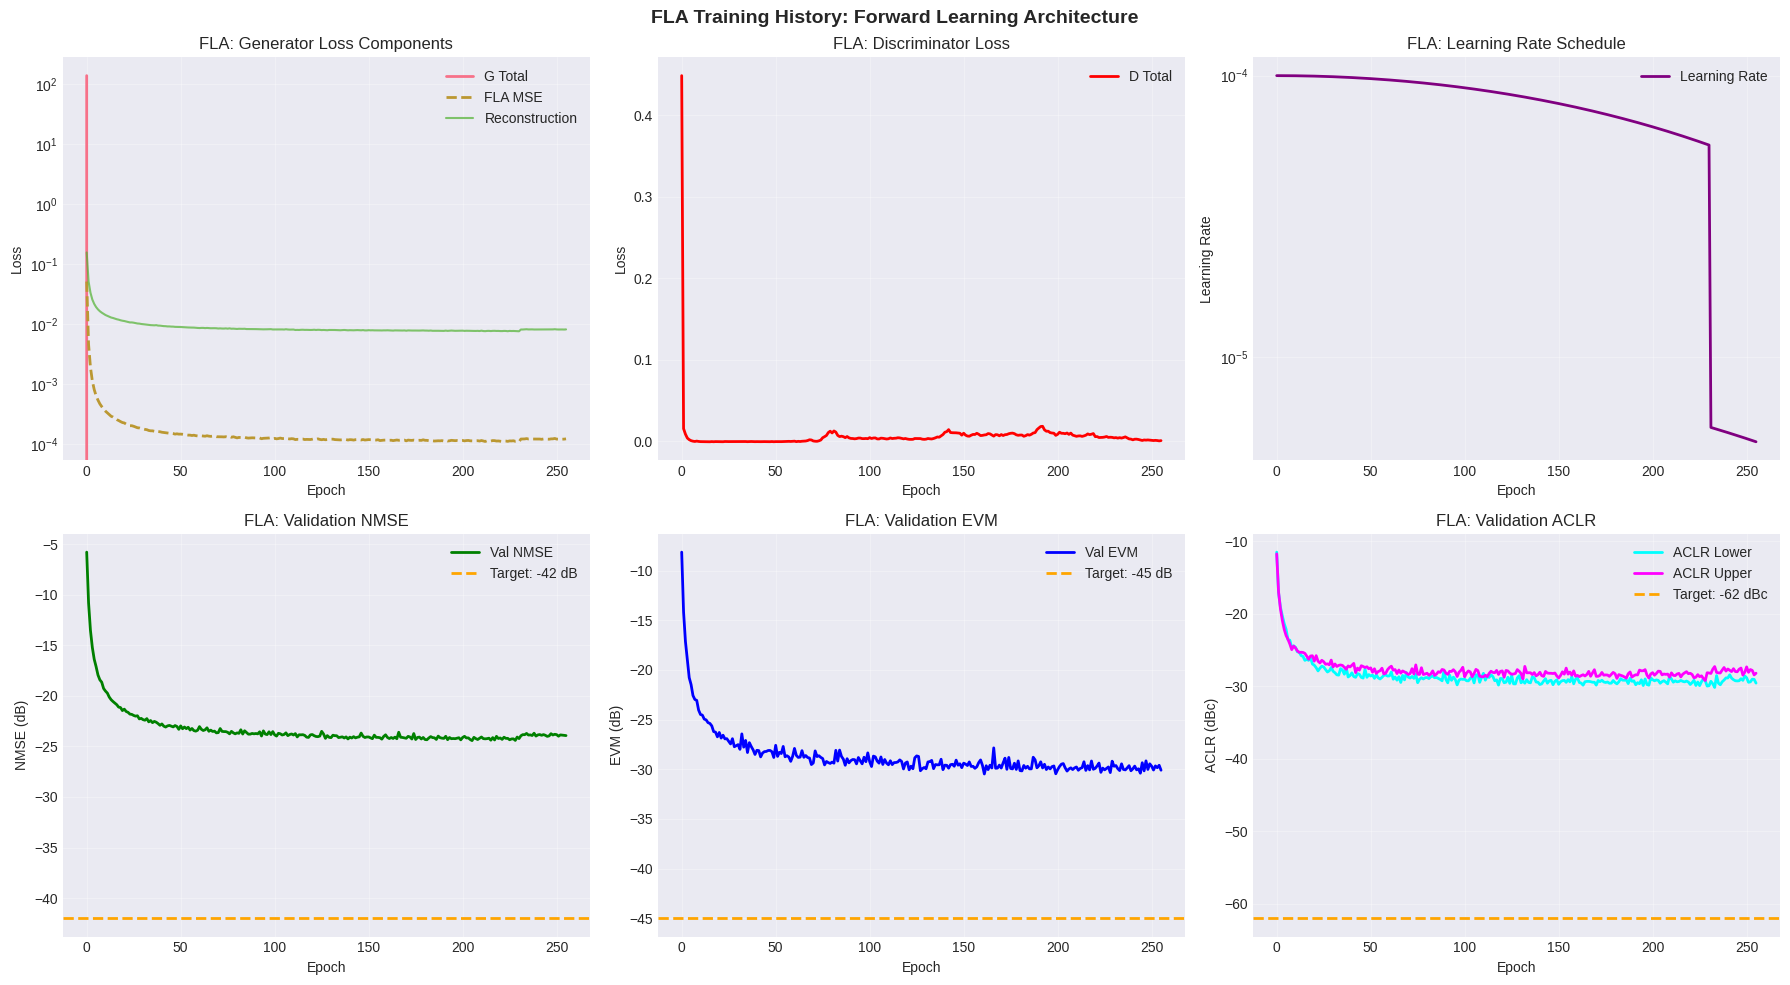


FLA TRAINING SUMMARY
Final Metrics:
  NMSE: -23.93 dB (Best: -24.43 dB)
  EVM:  -30.10 dB
  ACLR: -29.58/-28.21 dBc

Target Achievement:
  NMSE < -42 dB: ❌ FAIL
  EVM < -45 dB:  ❌ FAIL
  ACLR < -62 dBc: ❌ FAIL


In [62]:
# ================================================================================
# FLA: Training Visualization
# ================================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Generator Loss
ax = axes[0, 0]
ax.semilogy(history_fla['g_total'], label='G Total', linewidth=2)
ax.semilogy(history_fla['g_fla_mse'], label='FLA MSE', linewidth=2, linestyle='--')
ax.semilogy(history_fla['g_recon'], label='Reconstruction', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('FLA: Generator Loss Components')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Discriminator Loss
ax = axes[0, 1]
ax.plot(history_fla['d_total'], label='D Total', linewidth=2, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('FLA: Discriminator Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[0, 2]
ax.semilogy(history_fla['lr'], label='Learning Rate', linewidth=2, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('FLA: Learning Rate Schedule')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Validation NMSE
ax = axes[1, 0]
ax.plot(history_fla['val_nmse_db'], label='Val NMSE', linewidth=2, color='green')
ax.axhline(y=-42, color='orange', linestyle='--', linewidth=2, label='Target: -42 dB')
ax.fill_between(range(len(history_fla['val_nmse_db'])), -42, history_fla['val_nmse_db'],
                where=np.array(history_fla['val_nmse_db']) < -42, alpha=0.2, color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('NMSE (dB)')
ax.set_title('FLA: Validation NMSE')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Validation EVM
ax = axes[1, 1]
ax.plot(history_fla['val_evm_db'], label='Val EVM', linewidth=2, color='blue')
ax.axhline(y=-45, color='orange', linestyle='--', linewidth=2, label='Target: -45 dB')
ax.fill_between(range(len(history_fla['val_evm_db'])), -45, history_fla['val_evm_db'],
                where=np.array(history_fla['val_evm_db']) < -45, alpha=0.2, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('EVM (dB)')
ax.set_title('FLA: Validation EVM')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Validation ACLR
ax = axes[1, 2]
ax.plot(history_fla['val_aclr_lower_db'], label='ACLR Lower', linewidth=2, color='cyan')
ax.plot(history_fla['val_aclr_upper_db'], label='ACLR Upper', linewidth=2, color='magenta')
ax.axhline(y=-62, color='orange', linestyle='--', linewidth=2, label='Target: -62 dBc')
ax.set_xlabel('Epoch')
ax.set_ylabel('ACLR (dBc)')
ax.set_title('FLA: Validation ACLR')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('FLA Training History: Forward Learning Architecture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fla_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("FLA TRAINING SUMMARY")
print(f"{'='*70}")
print(f"Final Metrics:")
print(f"  NMSE: {history_fla['val_nmse_db'][-1]:.2f} dB (Best: {best_nmse_fla:.2f} dB)")
print(f"  EVM:  {history_fla['val_evm_db'][-1]:.2f} dB")
print(f"  ACLR: {history_fla['val_aclr_lower_db'][-1]:.2f}/{history_fla['val_aclr_upper_db'][-1]:.2f} dBc")
print(f"\nTarget Achievement:")
print(f"  NMSE < -42 dB: {'✅ PASS' if best_nmse_fla < -42 else '❌ FAIL'}")
print(f"  EVM < -45 dB:  {'✅ PASS' if history_fla['val_evm_db'][-1] < -45 else '❌ FAIL'}")
print(f"  ACLR < -62 dBc: {'✅ PASS' if history_fla['val_aclr_lower_db'][-1] < -62 and history_fla['val_aclr_upper_db'][-1] < -62 else '❌ FAIL'}")
print(f"{'='*70}")

FLA: BEFORE/AFTER CASCADED MODEL SPECTRUM COMPARISON


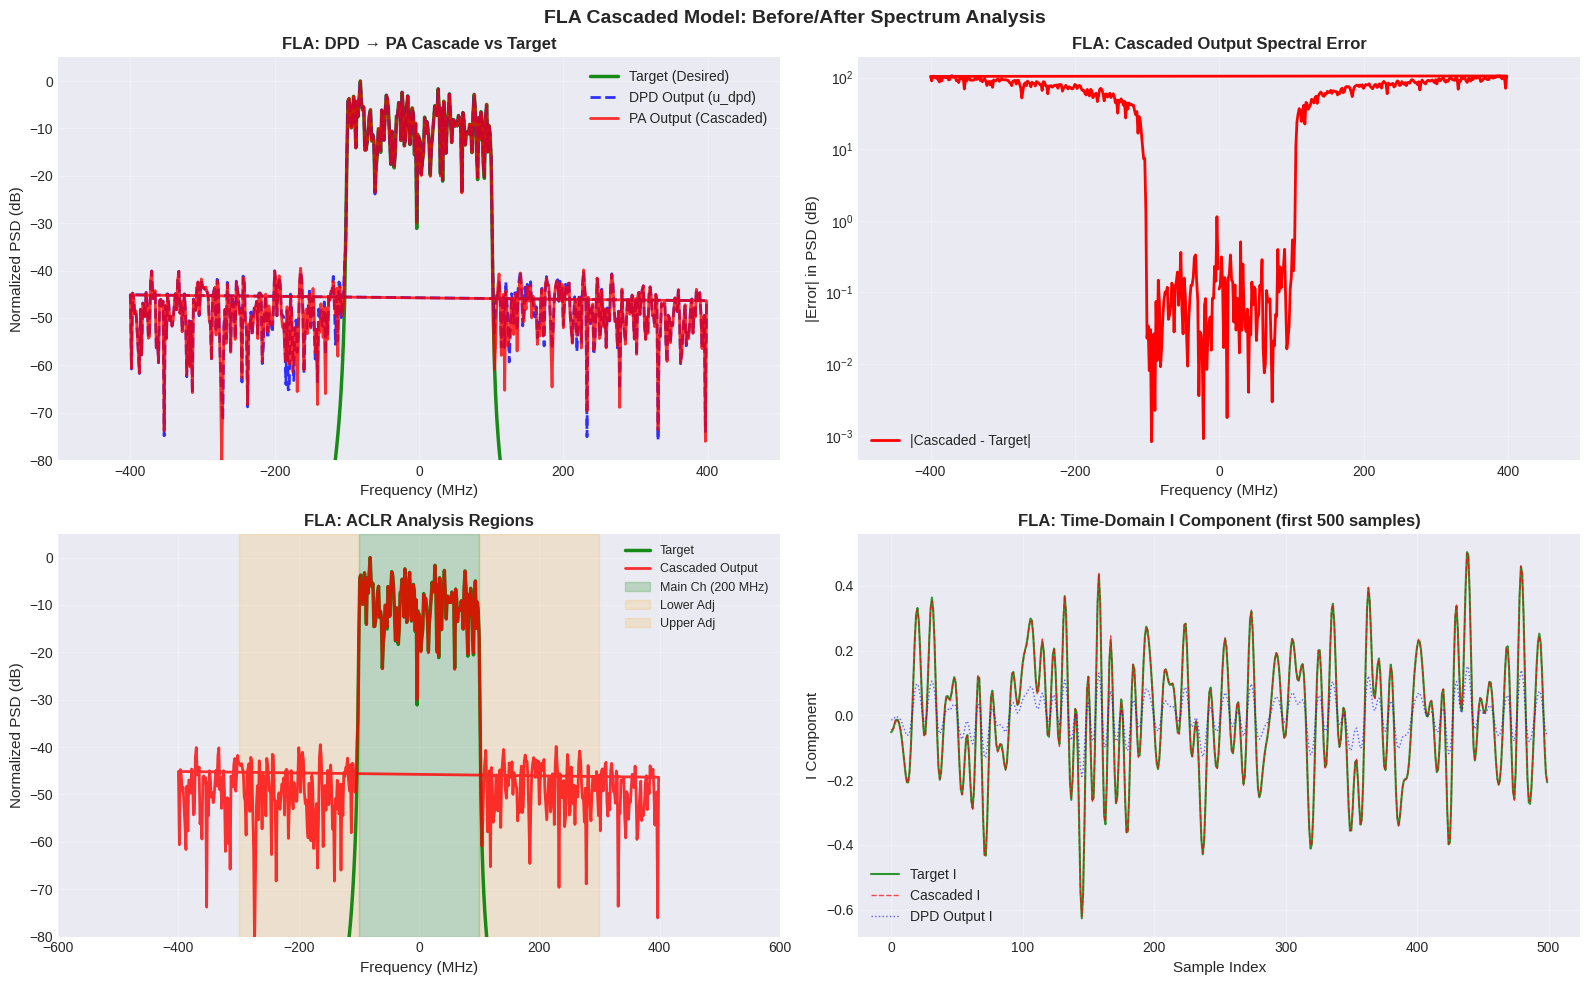


✓ FLA spectrum comparison plot saved: figures/fla_cascaded_spectrum_comparison.png

Aggregated samples analyzed: 640
Metrics on aggregated FLA data:
  EVM:        -37.72 dB (target: < -45 dB)
  NMSE:       -32.72 dB (target: < -42 dB)
  ACLR Left:  -100.00 dBc (target: < -62 dBc)
  ACLR Right: -19.73 dBc (target: < -62 dBc)

FLA Target Achievement:
  NMSE < -42 dB: ❌ FAIL
  EVM < -45 dB:  ❌ FAIL
  ACLR < -62 dBc: ❌ FAIL


/content/drive/MyDrive/FIX/6g-pa-gan-dpd/utils/spectral_loss.py:144: UserWarning: nperseg=2560 is greater than signal length max(len(x), len(y)) = 640, using nperseg = 640
  freq, psd = welch(complex_signal, fs=sample_rate, nperseg=nperseg,


In [64]:
# ================================================================================
# FLA: Before/After Cascaded Model Spectrum Analysis
# ================================================================================

print("="*70)
print("FLA: BEFORE/AFTER CASCADED MODEL SPECTRUM COMPARISON")
print("="*70)

# Set models to eval mode
cascaded_model.dpd.eval()
cascaded_model.pa.eval()

# Aggregate test samples
aggregated_dpd_input = []
aggregated_cascaded_output = []
aggregated_target = []

with torch.no_grad():
    # Use 10 batches to get enough samples for spectral analysis
    for i, (batch_input, batch_target, batch_clean_input) in enumerate(fla_val_loader):
        if i >= 10:
            break

        batch_input = batch_input.to(device)
        batch_clean_input = batch_clean_input.to(device)

        # Forward through cascaded model
        y_cas, u_dpd = cascaded_model(batch_input)

        # Extract and store
        aggregated_dpd_input.append(u_dpd.cpu().numpy())  # DPD output
        aggregated_cascaded_output.append(y_cas.cpu().numpy())  # Cascaded output (after PA)
        aggregated_target.append(batch_clean_input.cpu().numpy())  # Desired output

aggregated_dpd_input = np.concatenate(aggregated_dpd_input, axis=0)  # [N, 2]
aggregated_cascaded_output = np.concatenate(aggregated_cascaded_output, axis=0)  # [N, 2]
aggregated_target = np.concatenate(aggregated_target, axis=0)  # [N, 2]

# Convert IQ to complex
dpd_input_complex = aggregated_dpd_input[:, 0] + 1j * aggregated_dpd_input[:, 1]  # DPD output
cascaded_complex = aggregated_cascaded_output[:, 0] + 1j * aggregated_cascaded_output[:, 1]  # Cascaded output
target_complex = aggregated_target[:, 0] + 1j * aggregated_target[:, 1]  # Desired output

# Compute Welch PSD
fs = config['system']['sample_rate']
nperseg = 512

freqs, psd_dpd = welch(dpd_input_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs, psd_cascaded = welch(cascaded_complex, fs=fs, nperseg=nperseg, scaling='spectrum')
freqs, psd_target = welch(target_complex, fs=fs, nperseg=nperseg, scaling='spectrum')

# Normalize to dBm/Hz
psd_dpd_db = 10 * np.log10(psd_dpd + 1e-20)
psd_cascaded_db = 10 * np.log10(psd_cascaded + 1e-20)
psd_target_db = 10 * np.log10(psd_target + 1e-20)

# Create FLA comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

freqs_mhz = freqs / 1e6

# ===== Spectrum Comparison: DPD Output vs PA Output (Cascaded) =====
ax = axes[0, 0]
psd_dpd_norm = psd_dpd_db - np.max(psd_dpd_db)
psd_cascaded_norm = psd_cascaded_db - np.max(psd_cascaded_db)
psd_target_norm = psd_target_db - np.max(psd_target_db)

ax.plot(freqs_mhz, psd_target_norm, label='Target (Desired)', linewidth=2.5, color='green', alpha=0.9)
ax.plot(freqs_mhz, psd_dpd_norm, label='DPD Output (u_dpd)', linewidth=2, color='blue', alpha=0.8, linestyle='--')
ax.plot(freqs_mhz, psd_cascaded_norm, label='PA Output (Cascaded)', linewidth=2, color='red', alpha=0.8)
ax.set_xlim([-500, 500])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('FLA: DPD → PA Cascade vs Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ===== Cascaded Output vs Target Error =====
ax = axes[0, 1]
cascaded_error = psd_cascaded_db - psd_target_db
ax.semilogy(freqs_mhz, np.abs(cascaded_error), linewidth=2, color='red', label='|Cascaded - Target|')
ax.set_xlim([-500, 500])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('|Error| in PSD (dB)', fontsize=11)
ax.set_title('FLA: Cascaded Output Spectral Error', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ===== ACLR Region Highlights =====
ax = axes[1, 0]
bw_main = 200e6

ax.plot(freqs_mhz, psd_target_norm, label='Target', linewidth=2.5, color='green', alpha=0.9)
ax.plot(freqs_mhz, psd_cascaded_norm, label='Cascaded Output', linewidth=2, color='red', alpha=0.8)

# Highlight main channel and adjacent channels
ax.axvspan(-bw_main/2/1e6, bw_main/2/1e6, alpha=0.2, color='green', label='Main Ch (200 MHz)')
ax.axvspan(-3*bw_main/2/1e6, -bw_main/2/1e6, alpha=0.15, color='orange', label='Lower Adj')
ax.axvspan(bw_main/2/1e6, 3*bw_main/2/1e6, alpha=0.15, color='orange', label='Upper Adj')

ax.set_xlim([-600, 600])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (MHz)', fontsize=11)
ax.set_ylabel('Normalized PSD (dB)', fontsize=11)
ax.set_title('FLA: ACLR Analysis Regions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ===== Time-domain Waveform Comparison =====
ax = axes[1, 1]
time_samples = min(500, len(target_complex))
time_idx = np.arange(time_samples)

ax.plot(time_idx, target_complex[:time_samples].real, label='Target I', linewidth=1.5, alpha=0.8, color='green')
ax.plot(time_idx, cascaded_complex[:time_samples].real, label='Cascaded I', linewidth=1, alpha=0.7, color='red', linestyle='--')
ax.plot(time_idx, dpd_input_complex[:time_samples].real, label='DPD Output I', linewidth=1, alpha=0.6, color='blue', linestyle=':')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('I Component', fontsize=11)
ax.set_title('FLA: Time-Domain I Component (first 500 samples)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('FLA Cascaded Model: Before/After Spectrum Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fla_cascaded_spectrum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ FLA spectrum comparison plot saved: figures/fla_cascaded_spectrum_comparison.png")
print(f"\nAggregated samples analyzed: {len(aggregated_cascaded_output)}")
print(f"Metrics on aggregated FLA data:")

# Compute metrics on aggregated FLA data
evm_fla = compute_evm(
    aggregated_cascaded_output.reshape(1, -1, 2),
    aggregated_target.reshape(1, -1, 2),
    sample_rate=fs,
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    return_db=True
)
nmse_fla = compute_nmse(
    aggregated_cascaded_output.reshape(1, -1, 2),
    aggregated_target.reshape(1, -1, 2),
    return_db=True
)
aclr_l_fla, aclr_r_fla = compute_aclr(
    aggregated_cascaded_output.reshape(1, -1, 2),
    sample_rate=fs,
    nperseg=config['spectral_loss']['nperseg'],
    bw_main_ch=config['spectral_loss']['bw_main_ch'],
    n_sub_ch=config['spectral_loss']['n_sub_ch'],
    return_db=True
)

print(f"  EVM:        {evm_fla:.2f} dB (target: < -45 dB)")
print(f"  NMSE:       {nmse_fla:.2f} dB (target: < -42 dB)")
print(f"  ACLR Left:  {aclr_l_fla:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Right: {aclr_r_fla:.2f} dBc (target: < -62 dBc)")

# Target achievement summary
print(f"\nFLA Target Achievement:")
print(f"  NMSE < -42 dB: {'✅ PASS' if nmse_fla < -42 else '❌ FAIL'}")
print(f"  EVM < -45 dB:  {'✅ PASS' if evm_fla < -45 else '❌ FAIL'}")
print(f"  ACLR < -62 dBc: {'✅ PASS' if aclr_l_fla < -62 and aclr_r_fla < -62 else '❌ FAIL'}")
print("="*70)

In [63]:
# ================================================================================
# FLA vs ILA Comparison (if ILA was trained)
# ================================================================================

# Check if ILA history exists
if 'history' in dir() and len(history.get('val_nmse_db', [])) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # NMSE Comparison
    ax = axes[0]
    ax.plot(history['val_nmse_db'], label='ILA', linewidth=2, color='blue')
    ax.plot(history_fla['val_nmse_db'], label='FLA', linewidth=2, color='green')
    ax.axhline(y=-42, color='orange', linestyle='--', linewidth=2, label='Target: -42 dB')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NMSE (dB)')
    ax.set_title('ILA vs FLA: Validation NMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # EVM Comparison
    ax = axes[1]
    ax.plot(history['val_evm_db'], label='ILA', linewidth=2, color='blue')
    ax.plot(history_fla['val_evm_db'], label='FLA', linewidth=2, color='green')
    ax.axhline(y=-45, color='orange', linestyle='--', linewidth=2, label='Target: -45 dB')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('EVM (dB)')
    ax.set_title('ILA vs FLA: Validation EVM')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Summary Table
    ax = axes[2]
    ax.axis('off')

    summary_data = [
        ['Metric', 'ILA', 'FLA', 'Target'],
        ['Best NMSE (dB)', f"{min(history['val_nmse_db']):.2f}", f"{best_nmse_fla:.2f}", '< -42'],
        ['Final EVM (dB)', f"{history['val_evm_db'][-1]:.2f}", f"{history_fla['val_evm_db'][-1]:.2f}", '< -45'],
        ['Final ACLR Lower', f"{history['val_aclr_lower_db'][-1]:.2f}", f"{history_fla['val_aclr_lower_db'][-1]:.2f}", '< -62'],
        ['Final ACLR Upper', f"{history['val_aclr_upper_db'][-1]:.2f}", f"{history_fla['val_aclr_upper_db'][-1]:.2f}", '< -62'],
    ]

    table = ax.table(
        cellText=summary_data[1:],
        colLabels=summary_data[0],
        cellLoc='center',
        loc='center',
        colWidths=[0.3, 0.2, 0.2, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # Style header
    for i in range(4):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    ax.set_title('ILA vs FLA: Comparison Summary', fontsize=12, fontweight='bold', pad=20)

    plt.suptitle('ILA vs FLA Training Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/ila_vs_fla_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Determine winner
    ila_nmse = min(history['val_nmse_db'])
    fla_nmse = best_nmse_fla

    print(f"\n{'='*70}")
    print("ILA vs FLA COMPARISON")
    print(f"{'='*70}")
    if fla_nmse < ila_nmse:
        print(f"✅ FLA achieves better NMSE: {fla_nmse:.2f} dB vs ILA {ila_nmse:.2f} dB")
        print(f"   Improvement: {ila_nmse - fla_nmse:.2f} dB")
    else:
        print(f"⚠️ ILA achieves better NMSE: {ila_nmse:.2f} dB vs FLA {fla_nmse:.2f} dB")
        print(f"   Consider tuning FLA hyperparameters or PA model accuracy")
    print(f"{'='*70}")
else:
    print("ILA training history not found. Run ILA training first for comparison.")
    print("FLA training completed independently.")

ILA training history not found. Run ILA training first for comparison.
FLA training completed independently.
